<div style="
    max-width: 1000px;
    margin: 0 auto 40px auto;
    border-radius: 18px;
    overflow: hidden;
    box-shadow: 0 18px 45px rgba(0,0,0,0.18);
    font-family: 'Segoe UI', Arial, sans-serif;
">
    <!-- Image Section -->
    <div style="position: relative;">
        <img src="https://www.kaggle.com/competitions/125197/images/header"
             style="width:100%; display:block;">
        <!-- Overlay -->
        <div style="
            position:absolute;
            bottom:0;
            left:0;
            width:100%;
            background: linear-gradient(to top, rgba(10,25,47,0.9), rgba(10,25,47,0.35));
            padding:45px 55px;
            color:white;
        ">
            <h1 style="
                margin:0;
                font-size:40px;
                font-weight:700;
                letter-spacing:0.5px;
            ">
                Playground Series S6E3 – Customer Churn Prediction
            </h1>
            <p style="
                margin-top:12px;
                font-size:19px;
                opacity:0.95;
            ">
                Advanced EDA + Feature Engineering + Stacking Ensemble
            </p>
        </div>
    </div>
    <!-- Description Section -->
    <div style="
        background-color:#eef3f8;
        padding:45px 60px;
        line-height:1.75;
        font-size:17px;
        color:#1c2b3a;
        text-align: left;
    ">
        <p style="margin-top:0;">
        This notebook presents a structured, high-performance solution for Customer Churn Prediction.
        The workflow combines deep exploratory analysis, engineered features,
        and a large-capacity stacked ensemble optimized for <strong>ROC–AUC</strong>.
        </p>
        <ul style="
            margin-top:28px;
            padding-left:22px;
            line-height:1.9;
        ">
            <li><strong>Comprehensive Automated EDA</strong> – distribution diagnostics, skewness analysis, imbalance checks, feature–target interaction insights</li>
            <li><strong>Advanced Feature Engineering</strong> – tenure segmentation, service interaction indicators, service-count aggregation, normalized charge ratios</li>
            <li><strong>Robust Preprocessing Pipeline</strong> – median imputation, standard scaling, and One-Hot Encoding using <code>ColumnTransformer</code></li>
            <li><strong>Stratified 5-Fold Stacking Framework</strong> – leakage-free out-of-fold training for stable generalization</li>
            <li><strong>High-Capacity Boosting Models</strong> – XGBoost (hist), LightGBM (GPU), and CatBoost (GPU) configured with up to 50,000 estimators</li>
            <li><strong>Validation-Based Early Stopping</strong> – fold-level convergence control (500 rounds) to prevent overfitting</li>
            <li><strong>Meta-Learner Blending</strong> – L2-regularized Logistic Regression trained on OOF predictions for calibrated probability aggregation</li>
        </ul>
        <p style="
            margin-top:35px;
            font-size:15.5px;
            color:#3c4f65;
        ">
        The pipeline integrates multiple boosting models with early stopping and out-of-fold stacking to support stable cross-validated performance and reproducible experimentation.
        </p>
    </div>
</div>

In [1]:
import os
import sys
import gc
import time
import warnings
from typing import Optional, Tuple, List, Any

warnings.filterwarnings("ignore", message=".*use_label_encoder.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="Default metric period is 5 because AUC")
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from IPython.display import display, HTML

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import *

In [2]:
# ------------------------------------------------------------------------------
# Custom printing utilities
# ------------------------------------------------------------------------------

class Print:
    """
    Colourful console output using ANSI escape codes.
    Provides methods for info, success, warning, error, etc.
    """
    _RESET = '\033[0m'
    _BOLD = '\033[1m'
    _DIVIDER = '=' * 70

    # ANSI colour codes
    _CYAN = '\033[96m'
    _GREEN = '\033[92m'
    _YELLOW = '\033[93m'
    _RED = '\033[91m'
    _MAGENTA = '\033[95m'
    _BLUE = '\033[94m'

    @classmethod
    def _print(cls, colour: str, symbol: str, *args, **kwargs):
        """Base print method with colour and symbol."""
        message = ' '.join(str(a) for a in args)
        print(f"{cls._BOLD}{colour}{symbol} {message}{cls._RESET}", **kwargs)

    @classmethod
    def info(cls, *args, **kwargs):
        cls._print(cls._CYAN, '[i]', *args, **kwargs)

    @classmethod
    def success(cls, *args, **kwargs):
        cls._print(cls._GREEN, '[✓]', *args, **kwargs)

    @classmethod
    def warning(cls, *args, **kwargs):
        cls._print(cls._YELLOW, '[!]', *args, **kwargs)

    @classmethod
    def error(cls, *args, **kwargs):
        cls._print(cls._RED, '[✗]', *args, **kwargs)

    @classmethod
    def header(cls, *args, **kwargs):
        """Print a section header with a divider."""
        print()
        cls._print(cls._MAGENTA, '---', *args, **kwargs)
        print(cls._DIVIDER)

    @classmethod
    def divider(cls):
        print(cls._DIVIDER)

    @classmethod
    def blank(cls):
        print()

# ------------------------------------------------------------------------------
# Custom Print_table utility
# ------------------------------------------------------------------------------

def print_table(df: pd.DataFrame, title: Optional[str] = None, max_rows: int = 20):
    """
    Display a styled DataFrame in Jupyter.
    """
    
    df_disp = df.head(max_rows).copy()

    # Detect column types
    num_cols = df_disp.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df_disp.select_dtypes(include=["object", "category"]).columns.tolist()

    styled = df_disp.style

    # Base Table Styling 
    styled = styled.set_table_styles(
        [
            {
                "selector": "th",
                "props": [("background-color", "#2f3e46"),("color", "white"),("font-weight", "bold"),("text-align", "center"),("border", "1px solid #dddddd"),
                ],
            },
            {
                "selector": "td",
                "props": [("border", "1px solid #eeeeee"),("padding", "6px"),("text-align", "center"),
                ],
            },
            {
                "selector": "tr:hover",
                "props": [("background-color", "#f1f3f5")],
            },
        ]
    )

    # Numeric Styling 
    if num_cols:
        styled = styled.background_gradient(
            cmap="Blues",
            subset=num_cols
        ).format(precision=3)

    # Categorical Styling 
    if cat_cols:
        styled = styled.set_properties(
            subset=cat_cols,
            **{
                "background-color": "#fdf6e3",  # soft beige
                "color": "#333333",
            }
        )

    # Caption 
    if title:
        styled = styled.set_caption(title).set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "16px"),
                        ("font-weight", "bold"),
                        ("padding", "8px"),
                    ],
                }
            ],
            overwrite=False,
        )

    display(styled)

# ------------------------------------------------------------------------------
# Plotting style 
# ------------------------------------------------------------------------------

def set_plot_style():
    rcParams['figure.figsize'] = (12, 6)
    rcParams['axes.facecolor'] = '#f8f9fa'
    rcParams['figure.facecolor'] = 'white'
    rcParams['axes.grid'] = True
    rcParams['grid.alpha'] = 0.3
    rcParams['grid.color'] = '#cccccc'
    rcParams['axes.edgecolor'] = '#333333'
    rcParams['axes.linewidth'] = 1.2
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.size'] = 11
    rcParams['axes.labelsize'] = 12
    rcParams['axes.titlesize'] = 14
    rcParams['axes.titleweight'] = 'bold'
    rcParams['xtick.labelsize'] = 10
    rcParams['ytick.labelsize'] = 10
    rcParams['legend.fontsize'] = 10
    rcParams['legend.framealpha'] = 0.9

    # Custom colour palette
    global COLORS
    COLORS = ['#1e3c72', '#c31432', '#9D4EDD', '#C77DFF', '#E0AAFF', '#5A189A', '#240046']

    # Set seaborn palette
    sns.set_palette(sns.color_palette(COLORS))

    # Apply to matplotlib
    plt.rcParams.update(rcParams)

# EDA Pipeline 


--- DATA LOADING
[✓] Train shape: (594194, 21)
[✓] Test shape : (254655, 20)
[✓] Original shape: (7043, 21)

--- INSIGHTS: DATA LOADING
[i] Training set contains 594,194 rows and 21 columns.
[i] Test set contains 254,655 rows and 20 columns.
[i] Original dataset (IBM sample) has 7,043 rows.
[✓] Data loaded successfully. Target variable already binarized for training set.

--- DATASET OVERVIEW


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.100,1653.850,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.500,3778.200,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.400,5841.350,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.700,70.700,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.450,70.450,1
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.200,20.200,0
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.400,533.600,0
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.000,6827.500,0
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.550,79.550,1
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.050,4738.300,0


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,int64,object,int64,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,int64


,count,mean,std,min,25%,50%,75%,max
id,594194.000,297096.500,171529.177,0.000,148548.250,297096.500,445644.750,594193.000
SeniorCitizen,594194.000,0.114,0.318,0.000,0.000,0.000,0.000,1.000
tenure,594194.000,36.577,25.062,1.000,12.000,35.000,62.000,72.000
MonthlyCharges,594194.000,65.866,31.067,18.250,29.900,74.100,90.800,118.750
TotalCharges,594194.000,2494.377,2353.917,18.800,639.650,1433.650,4263.800,8684.800
Churn,594194.000,0.225,0.418,0.000,0.000,0.000,0.000,1.000


,Column,Dtype,Unique,Null_Count,Null_%,Sample_Values
0,id,int64,594194,0,0.00%,"[0, 1, 2]"
1,gender,object,2,0,0.00%,"['Male', 'Male', 'Male']"
2,SeniorCitizen,int64,2,0,0.00%,"[0, 0, 0]"
3,Partner,object,2,0,0.00%,"['Yes', 'Yes', 'Yes']"
4,Dependents,object,2,0,0.00%,"['Yes', 'Yes', 'No']"
5,tenure,int64,72,0,0.00%,"[29, 58, 58]"
6,PhoneService,object,2,0,0.00%,"['Yes', 'Yes', 'Yes']"
7,MultipleLines,object,3,0,0.00%,"['No', 'No', 'Yes']"
8,InternetService,object,3,0,0.00%,"['DSL', 'DSL', 'Fiber optic']"
9,OnlineSecurity,object,3,0,0.00%,"['Yes', 'Yes', 'No']"



--- INSIGHTS: DATASET OVERVIEW
[i] Found 6 numerical features and 15 categorical features.
[✓] All categorical columns have low cardinality (≤10 unique values).

--- MISSING VALUES ANALYSIS
[✓] No missing values detected.

--- INSIGHTS: MISSING VALUES
[✓] No missing values in either train or test set – great!

--- TARGET VARIABLE ANALYSIS


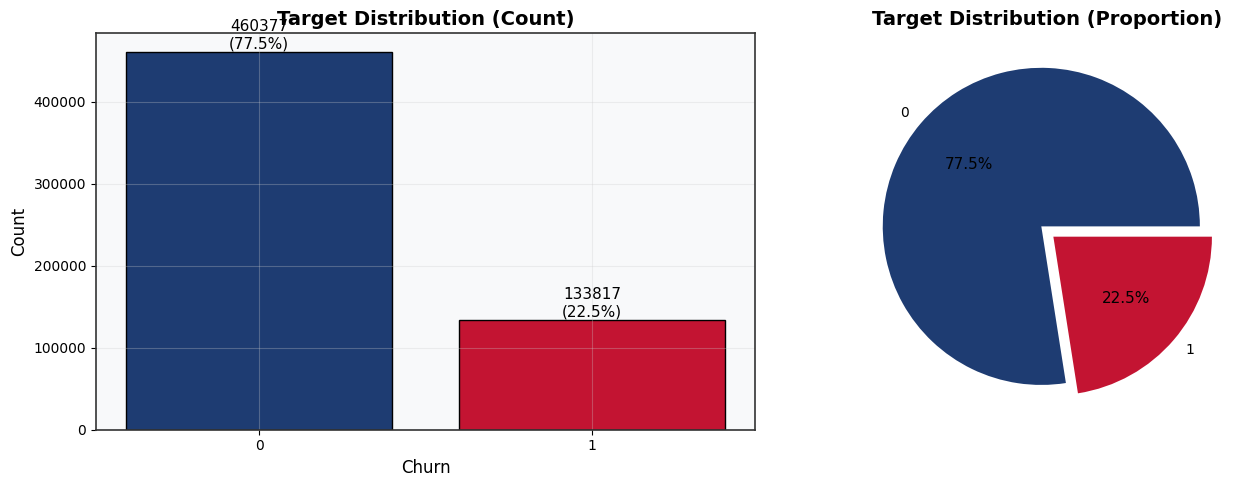

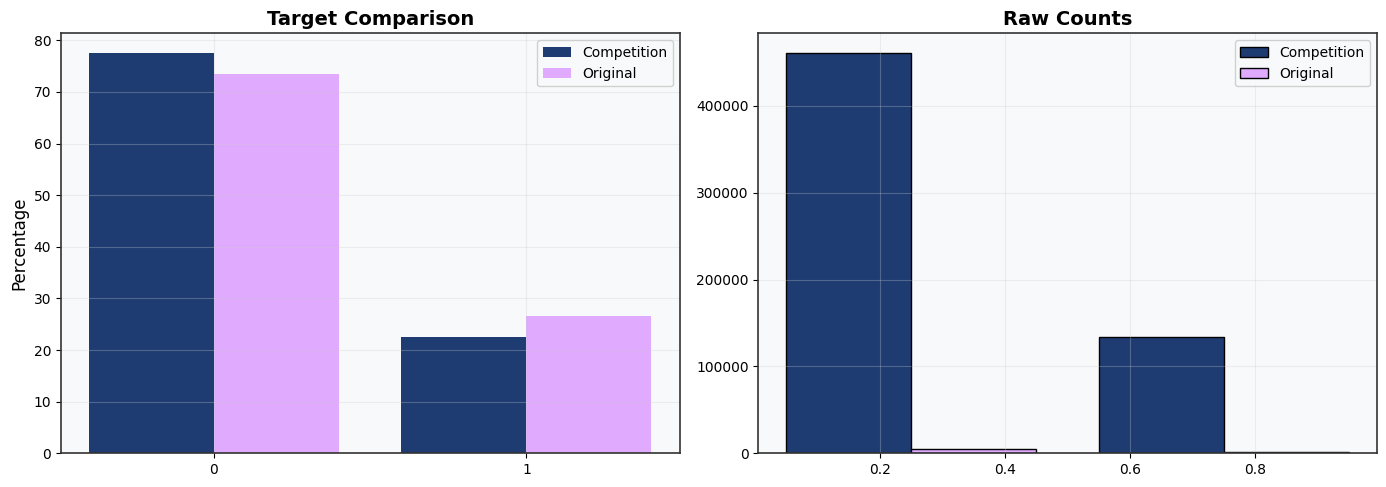

[i] Competition churn rate: 22.52%
[i] Original churn rate   : 26.54%

--- INSIGHTS: TARGET VARIABLE
[i] Overall churn rate in competition data: 22.52%.
[i] Class imbalance is mild.
[i] Original dataset churn rate: 26.54%.
[✓] Competition and original churn rates are similar.

--- NUMERICAL FEATURES ANALYSIS
[i] Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


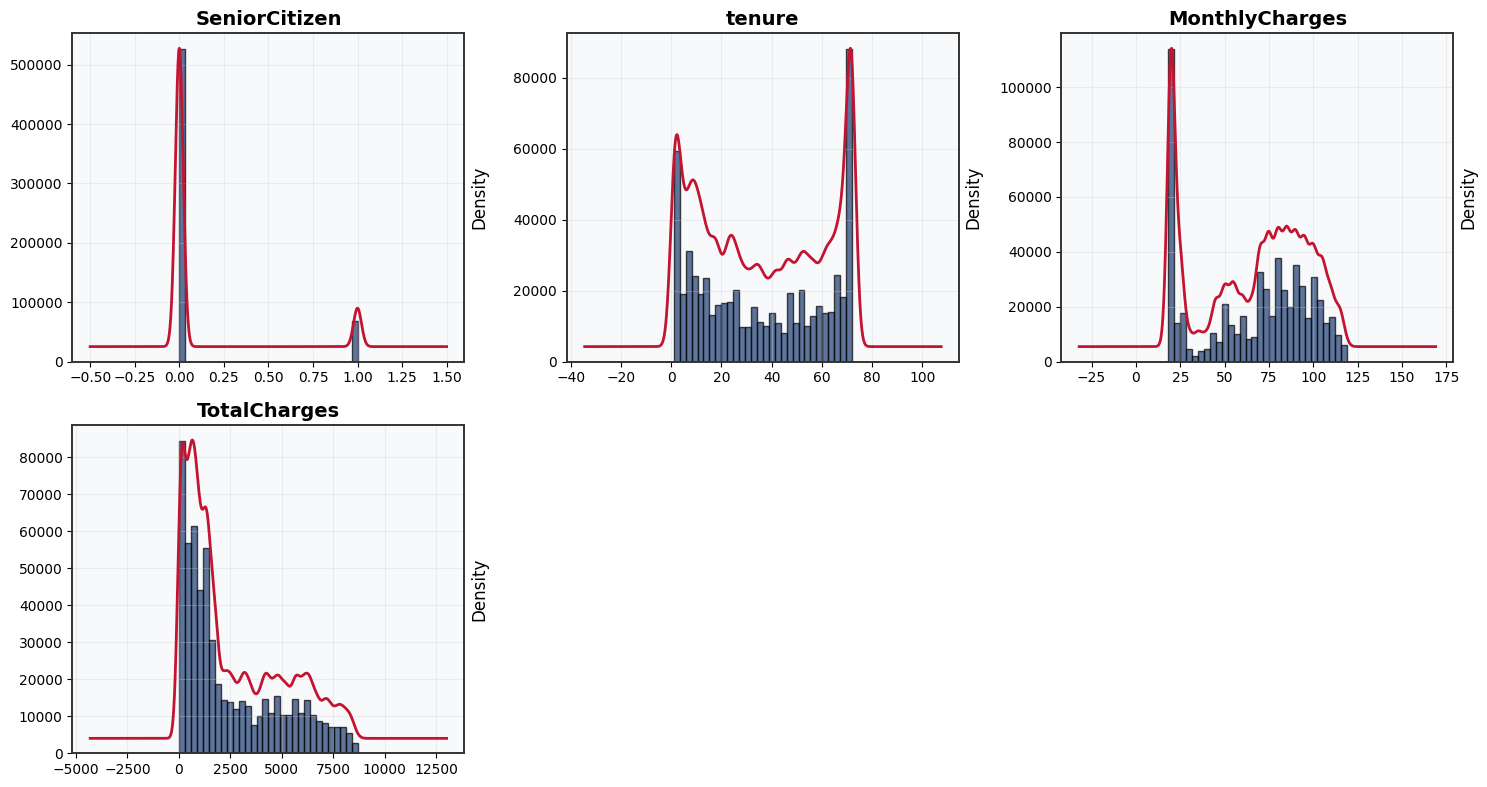

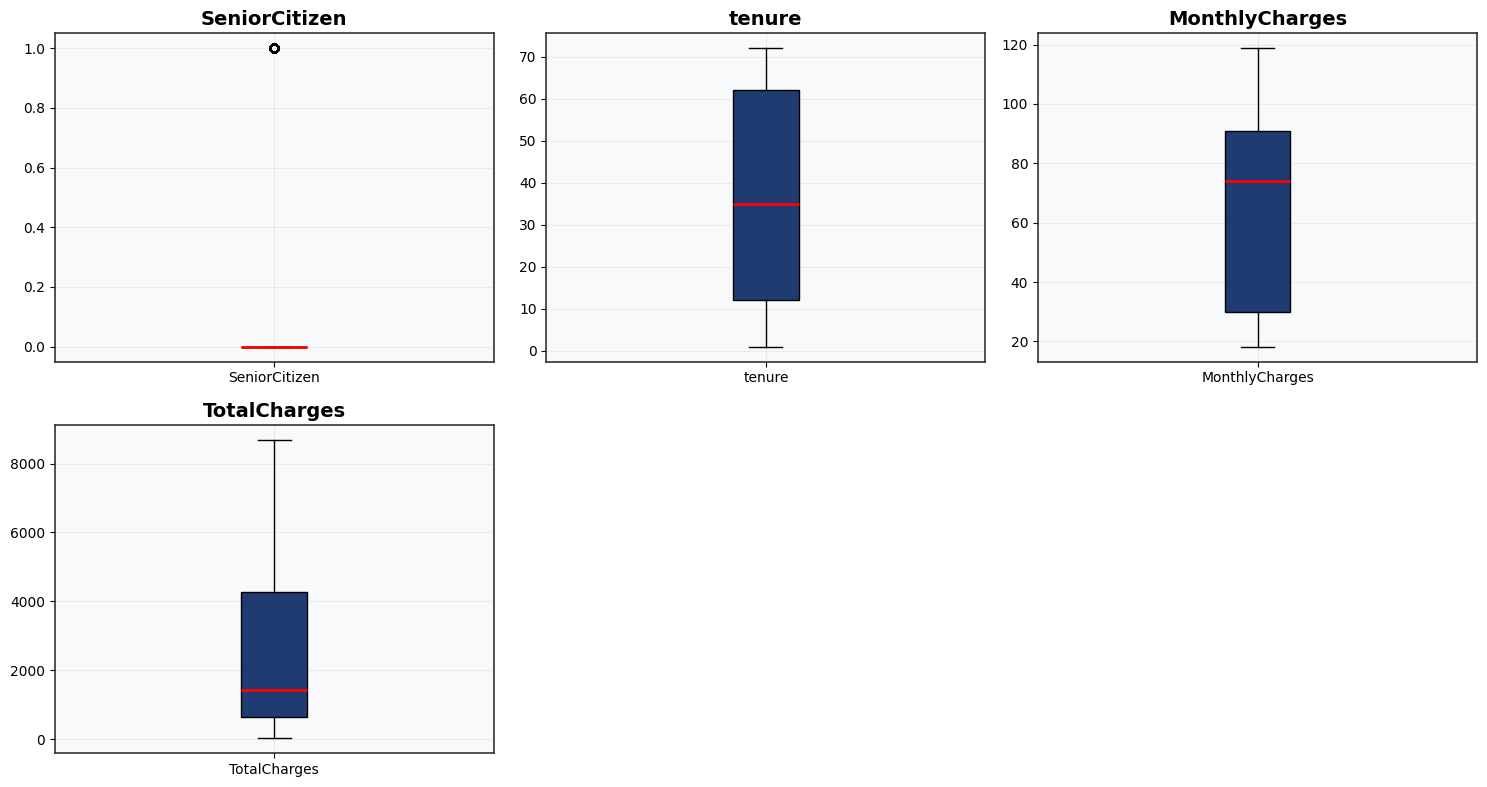

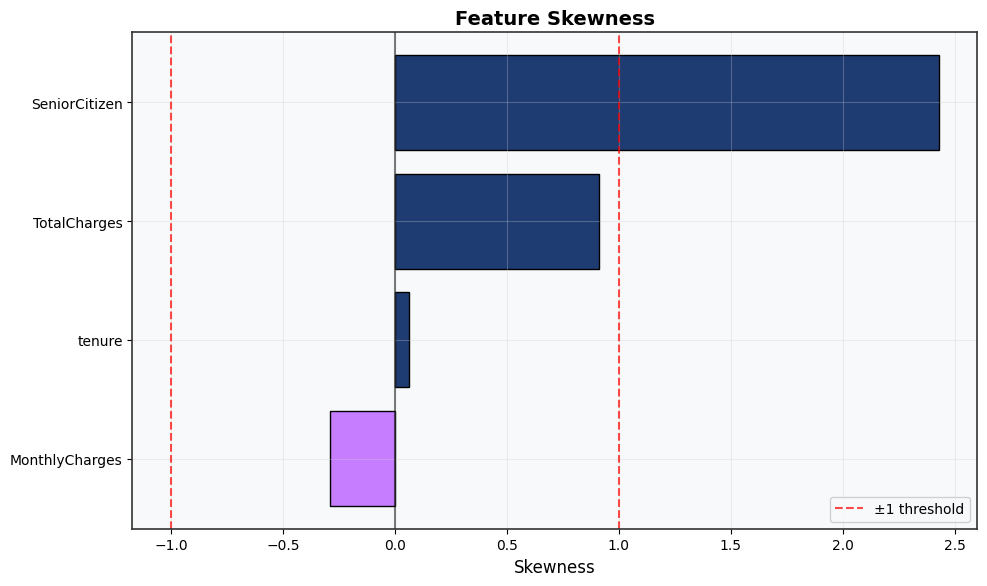


--- INSIGHTS: NUMERICAL FEATURES
[i] SeniorCitizen: mean = 0.11, std = 0.32, skew = 2.43
[i] tenure: mean = 36.58, std = 25.06, skew = 0.06
[i] MonthlyCharges: mean = 65.87, std = 31.07, skew = -0.29
[i] TotalCharges: mean = 2494.38, std = 2353.92, skew = 0.91
[!] Highly skewed features: ['SeniorCitizen']. Consider log or power transformations.
[!] Columns with outliers: {'SeniorCitizen': 67799}. Robust scaling or winsorization may help.

--- CATEGORICAL FEATURES ANALYSIS
[i] Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


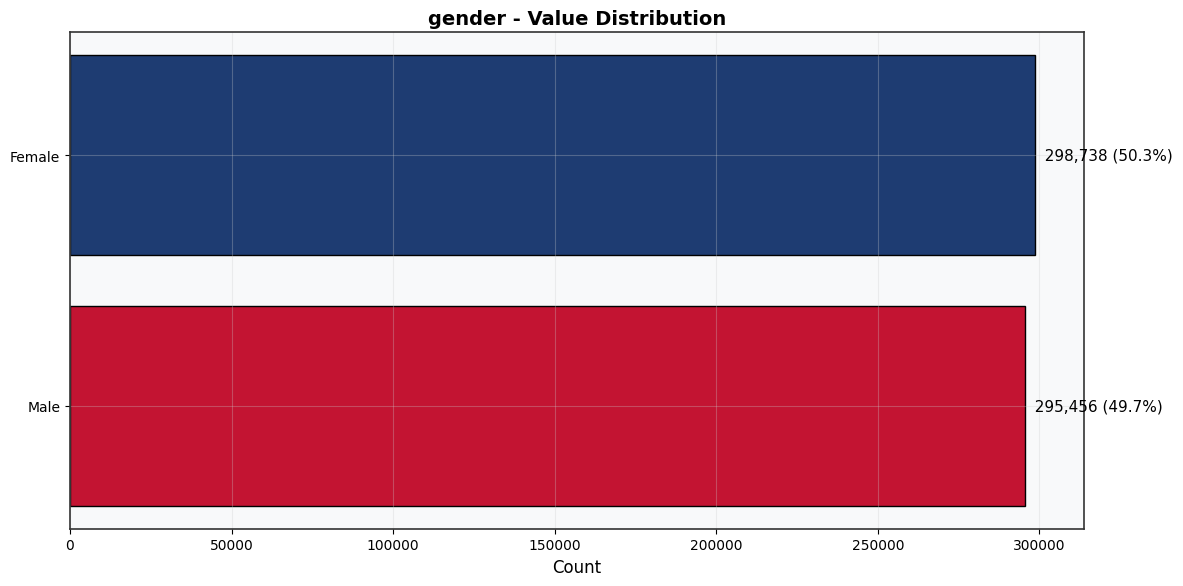

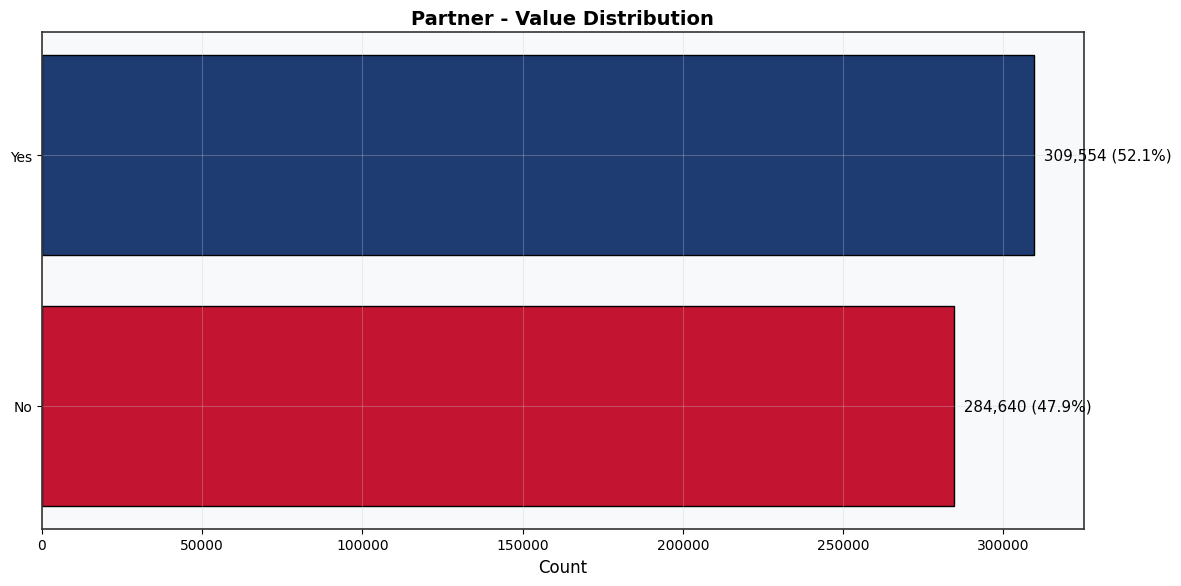

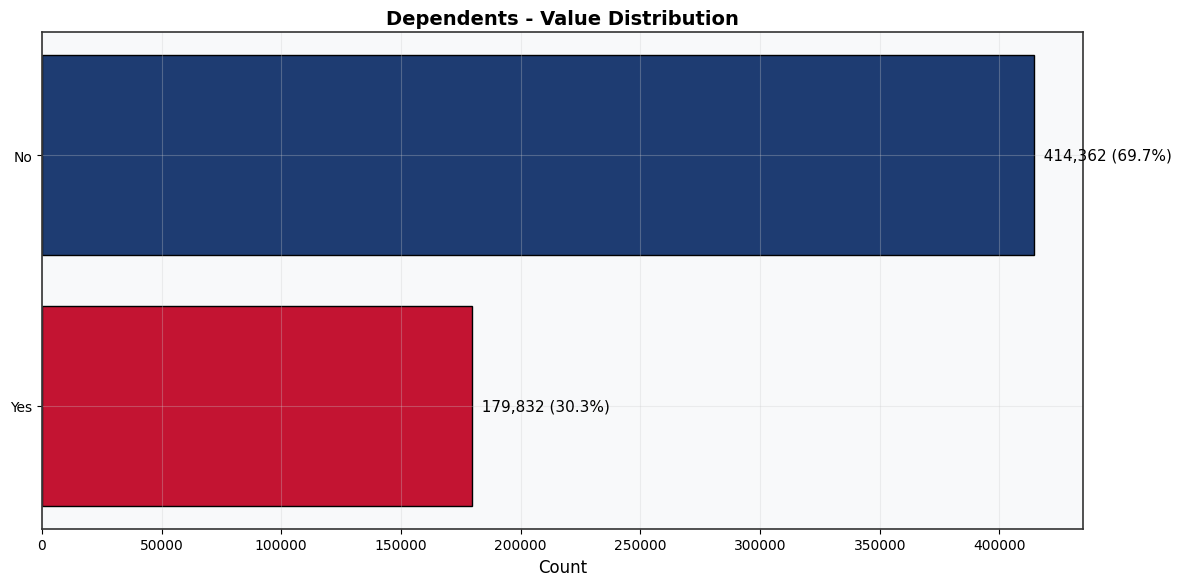

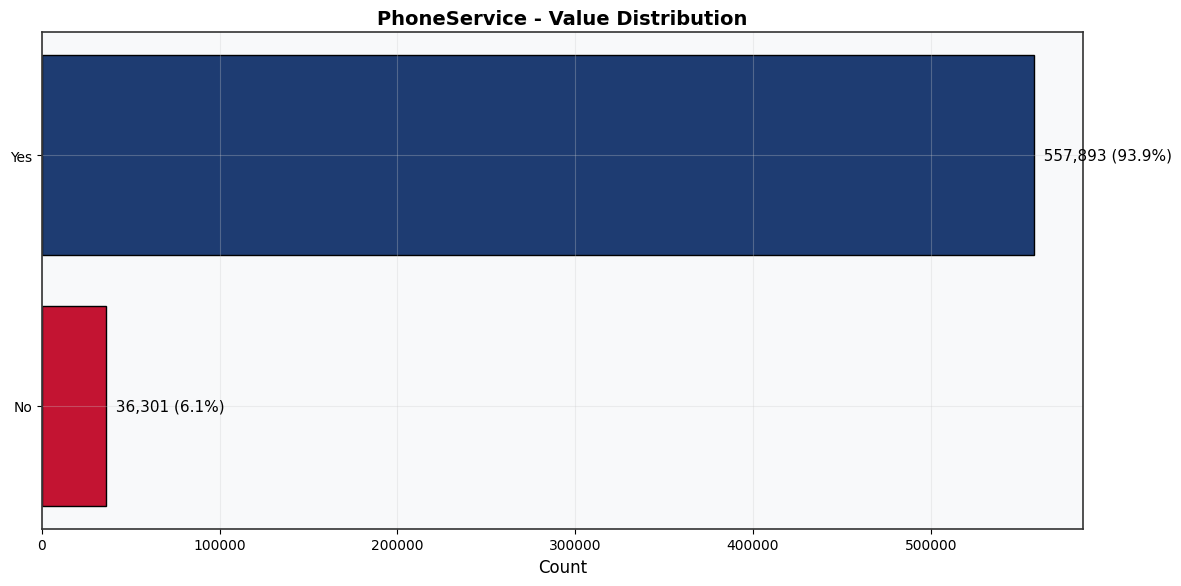

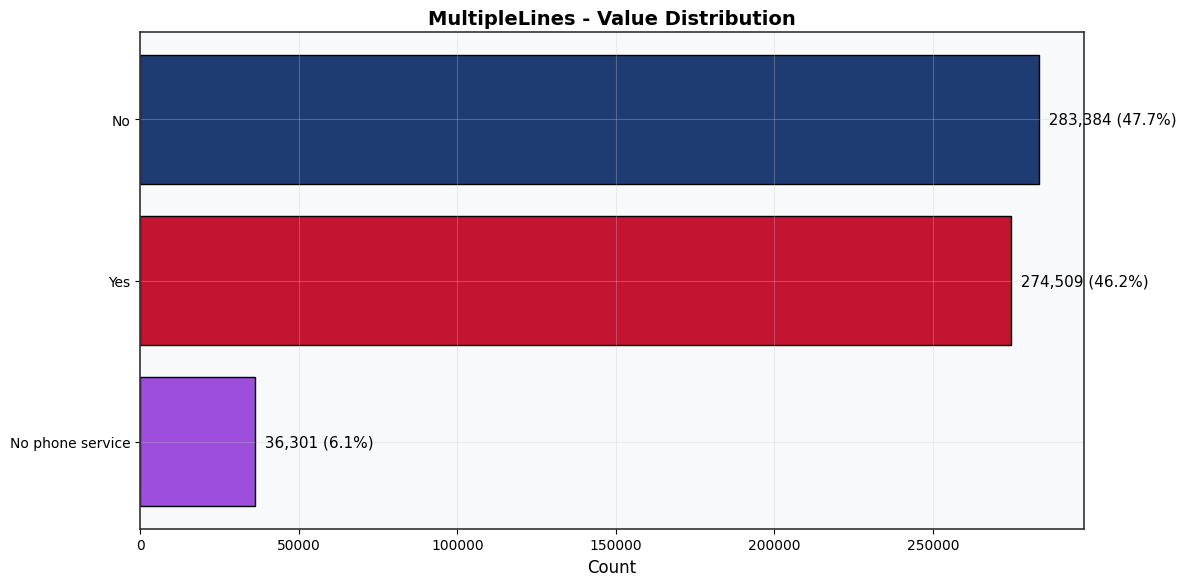

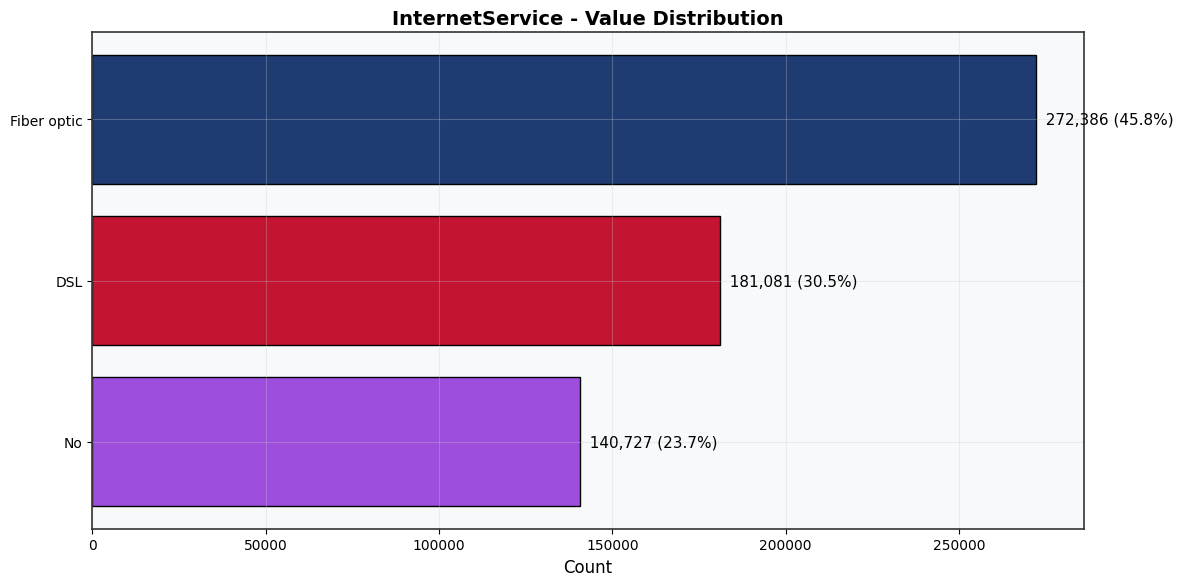

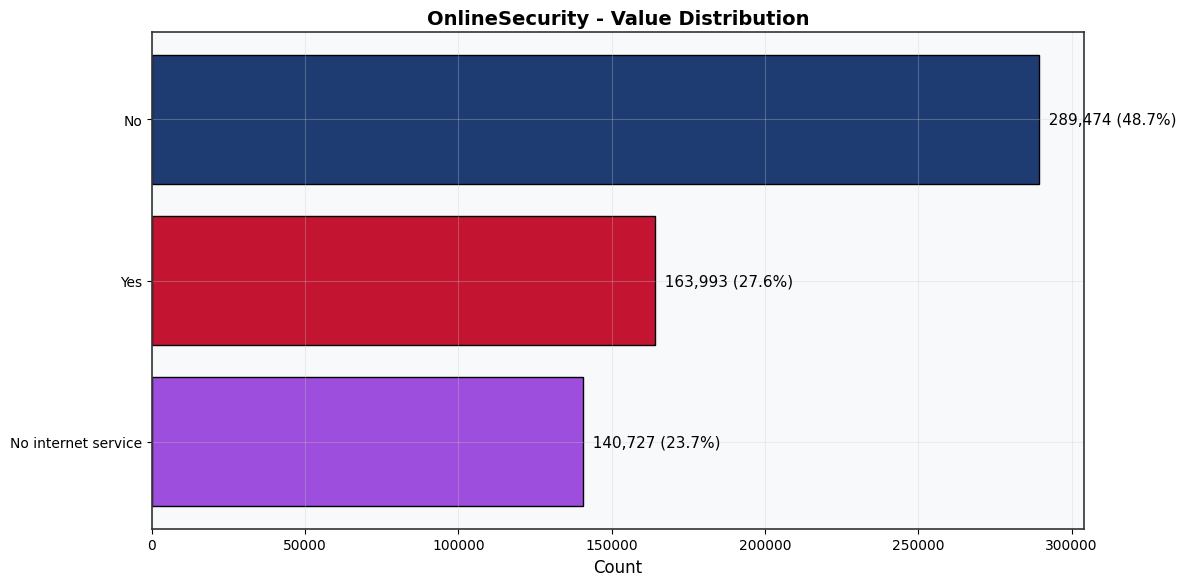

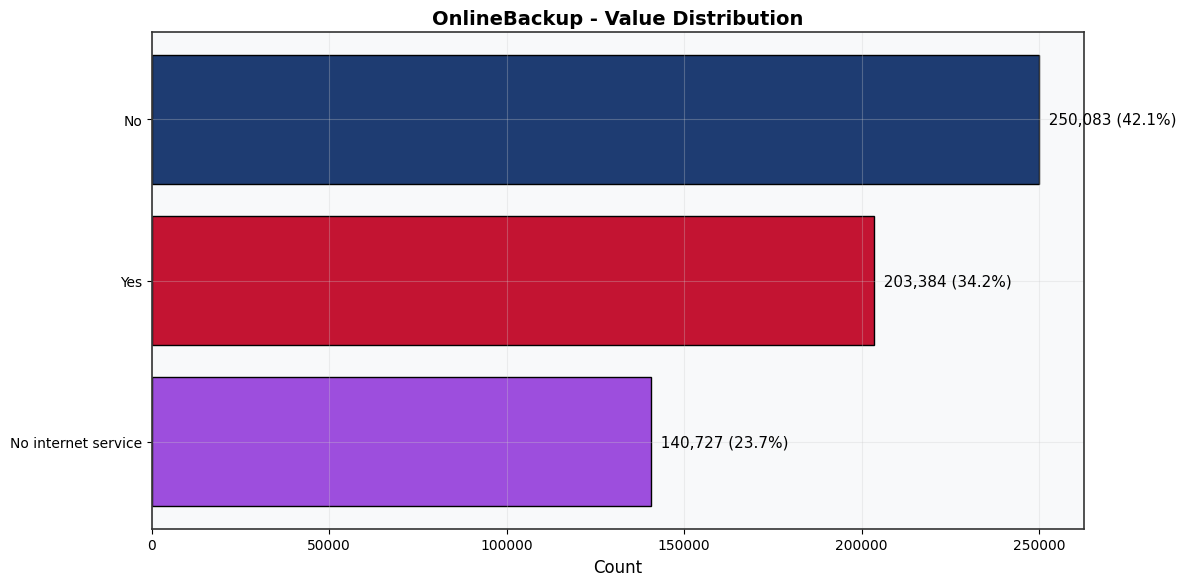

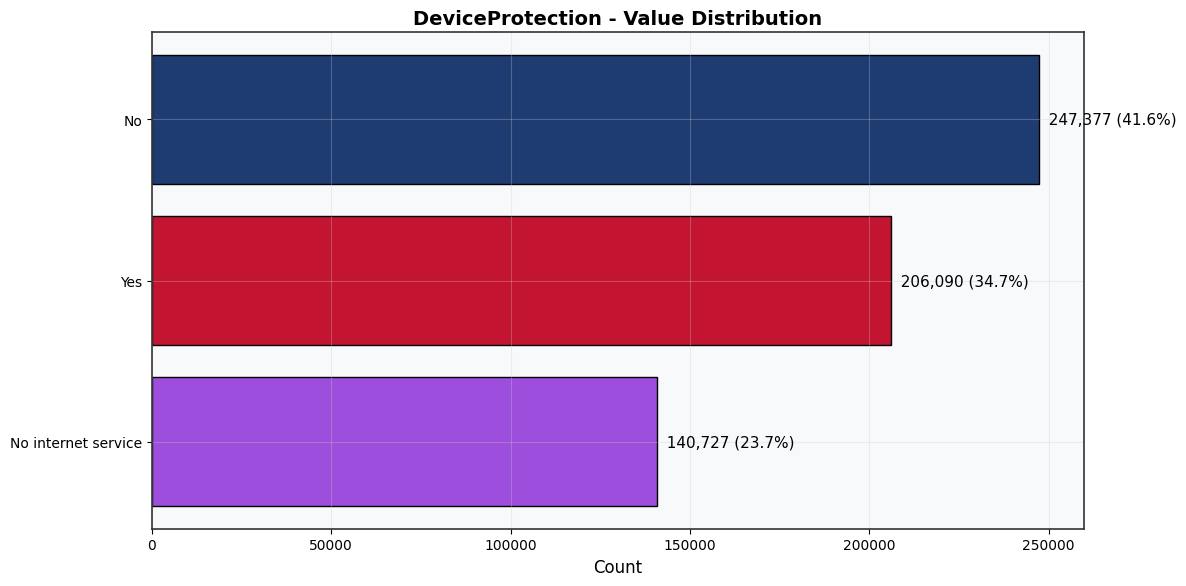

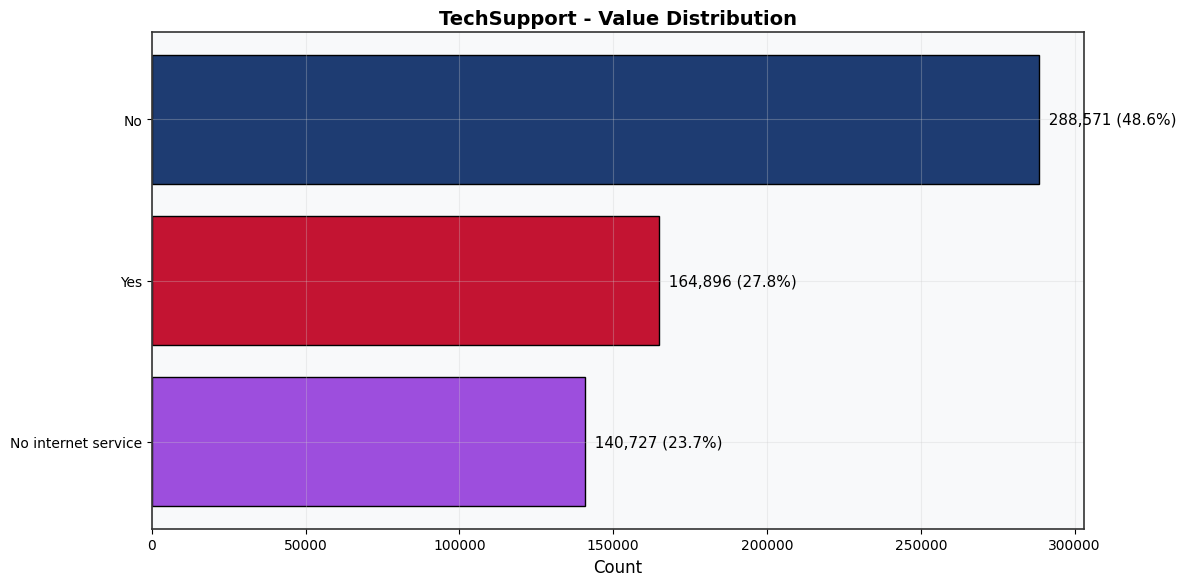

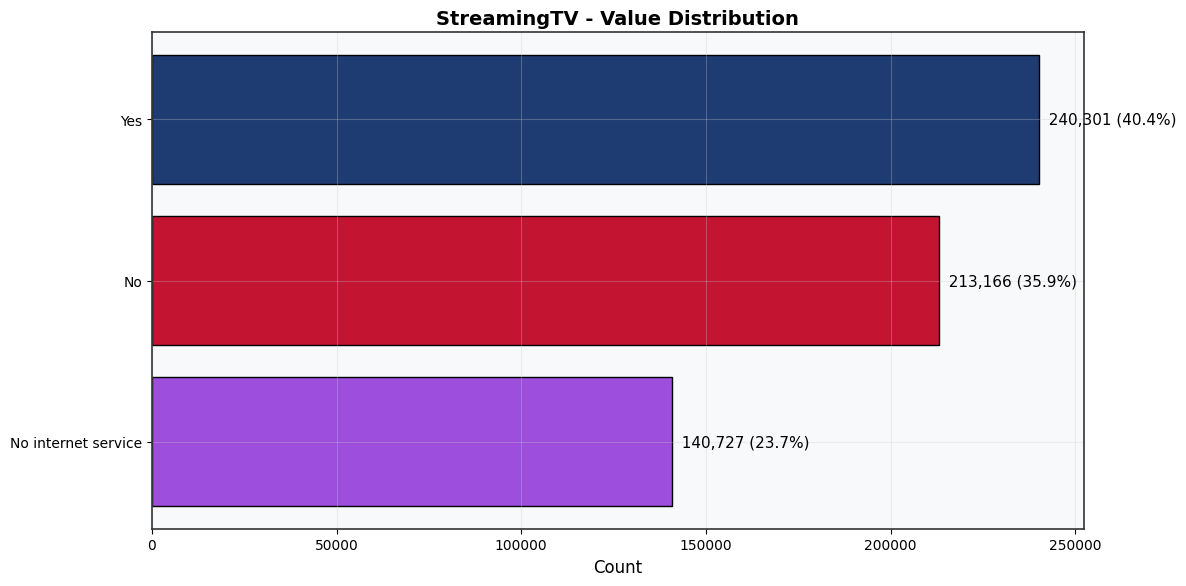

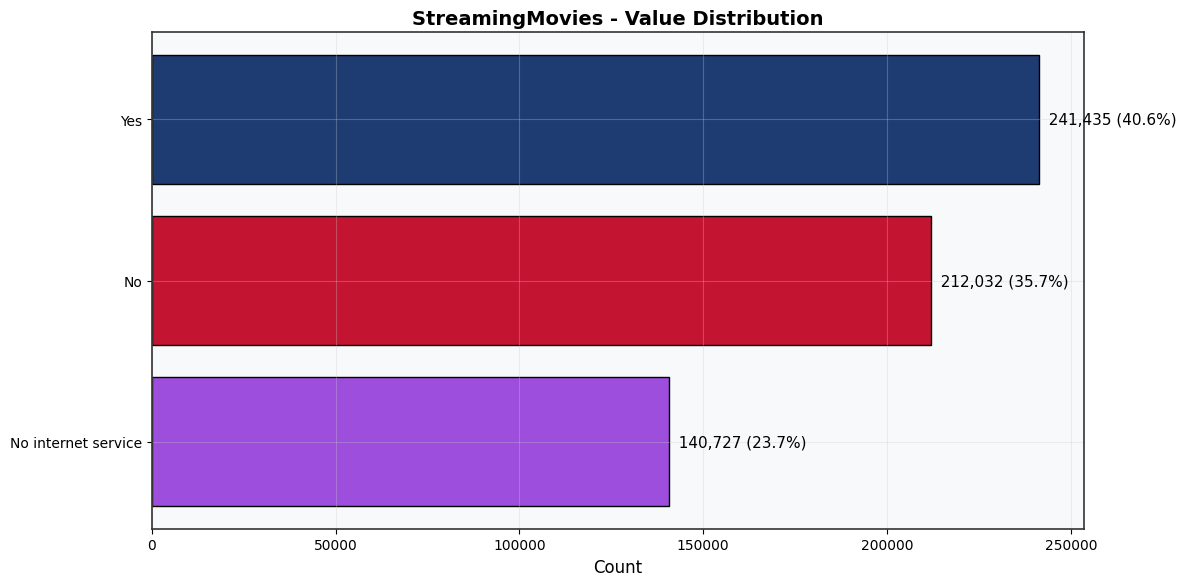

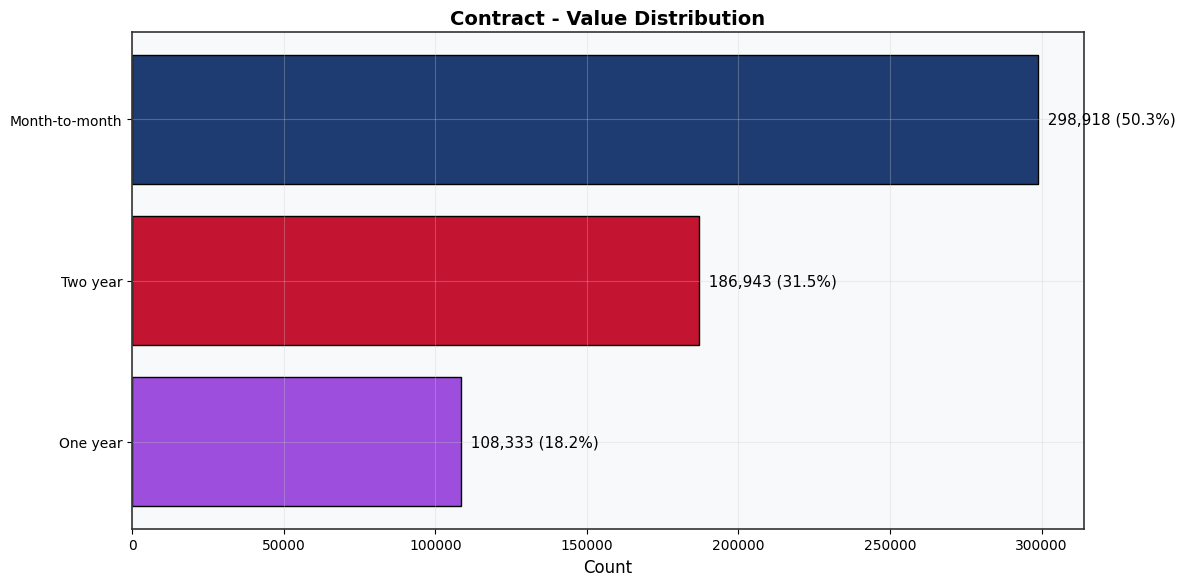

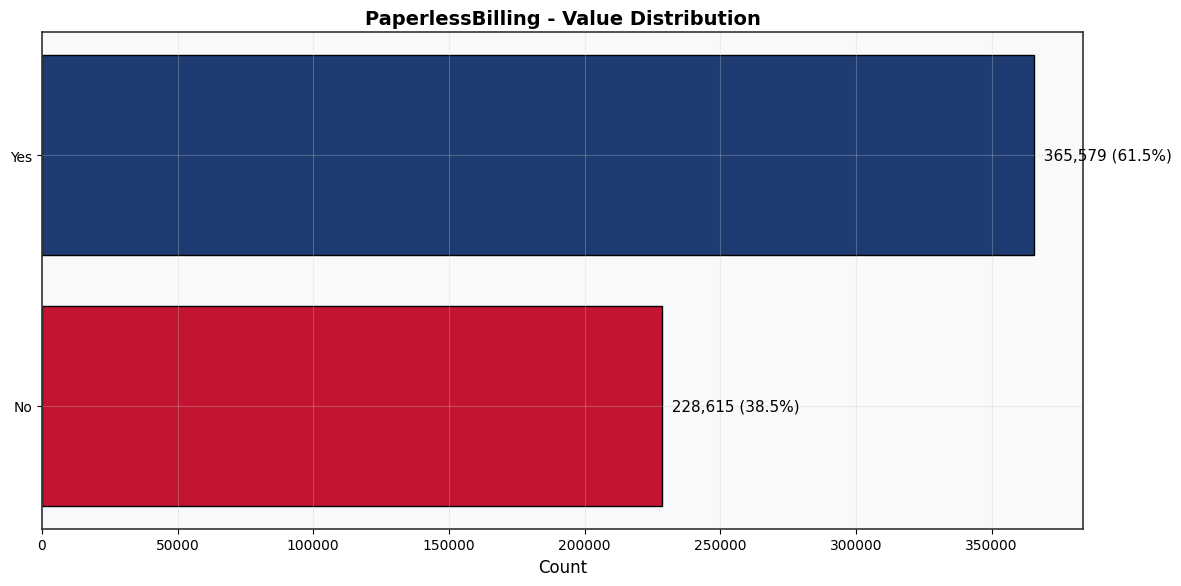

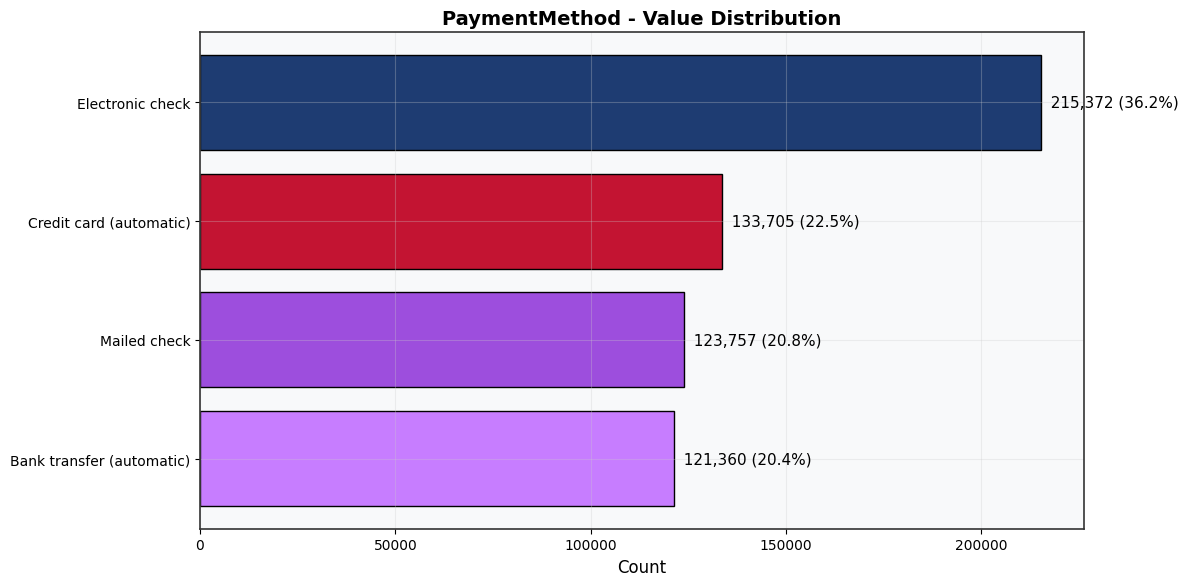

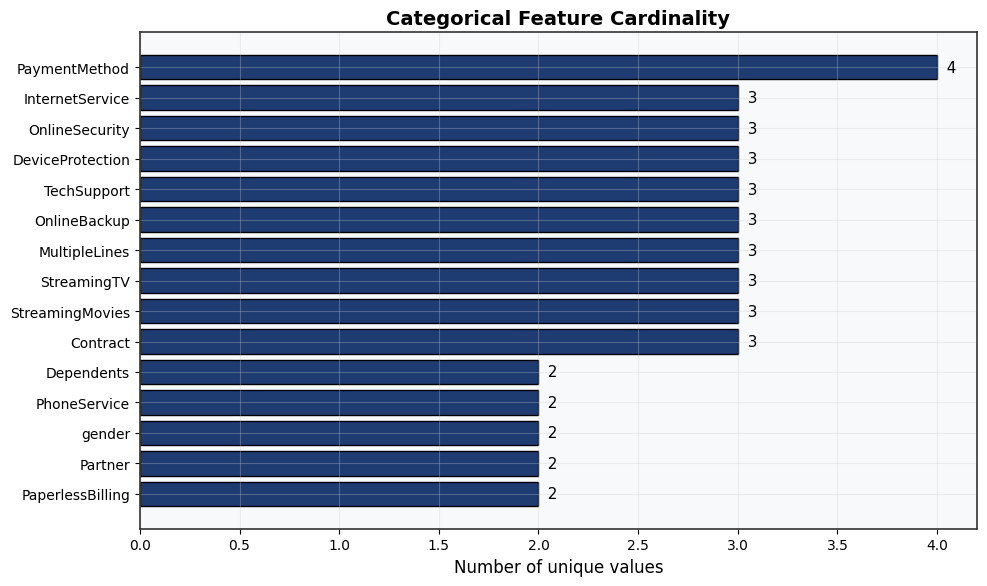


--- INSIGHTS: CATEGORICAL FEATURES
[i] gender: most frequent category 'Female' appears in 50.3% of rows.
[i] Partner: most frequent category 'Yes' appears in 52.1% of rows.
[i] Dependents: most frequent category 'No' appears in 69.7% of rows.
[i] PhoneService: most frequent category 'Yes' appears in 93.9% of rows.
[i] MultipleLines: most frequent category 'No' appears in 47.7% of rows.
[i] InternetService: most frequent category 'Fiber optic' appears in 45.8% of rows.
[i] OnlineSecurity: most frequent category 'No' appears in 48.7% of rows.
[i] OnlineBackup: most frequent category 'No' appears in 42.1% of rows.
[i] DeviceProtection: most frequent category 'No' appears in 41.6% of rows.
[i] TechSupport: most frequent category 'No' appears in 48.6% of rows.
[i] StreamingTV: most frequent category 'Yes' appears in 40.4% of rows.
[i] StreamingMovies: most frequent category 'Yes' appears in 40.6% of rows.
[i] Contract: most frequent category 'Month-to-month' appears in 50.3% of rows.
[i] P

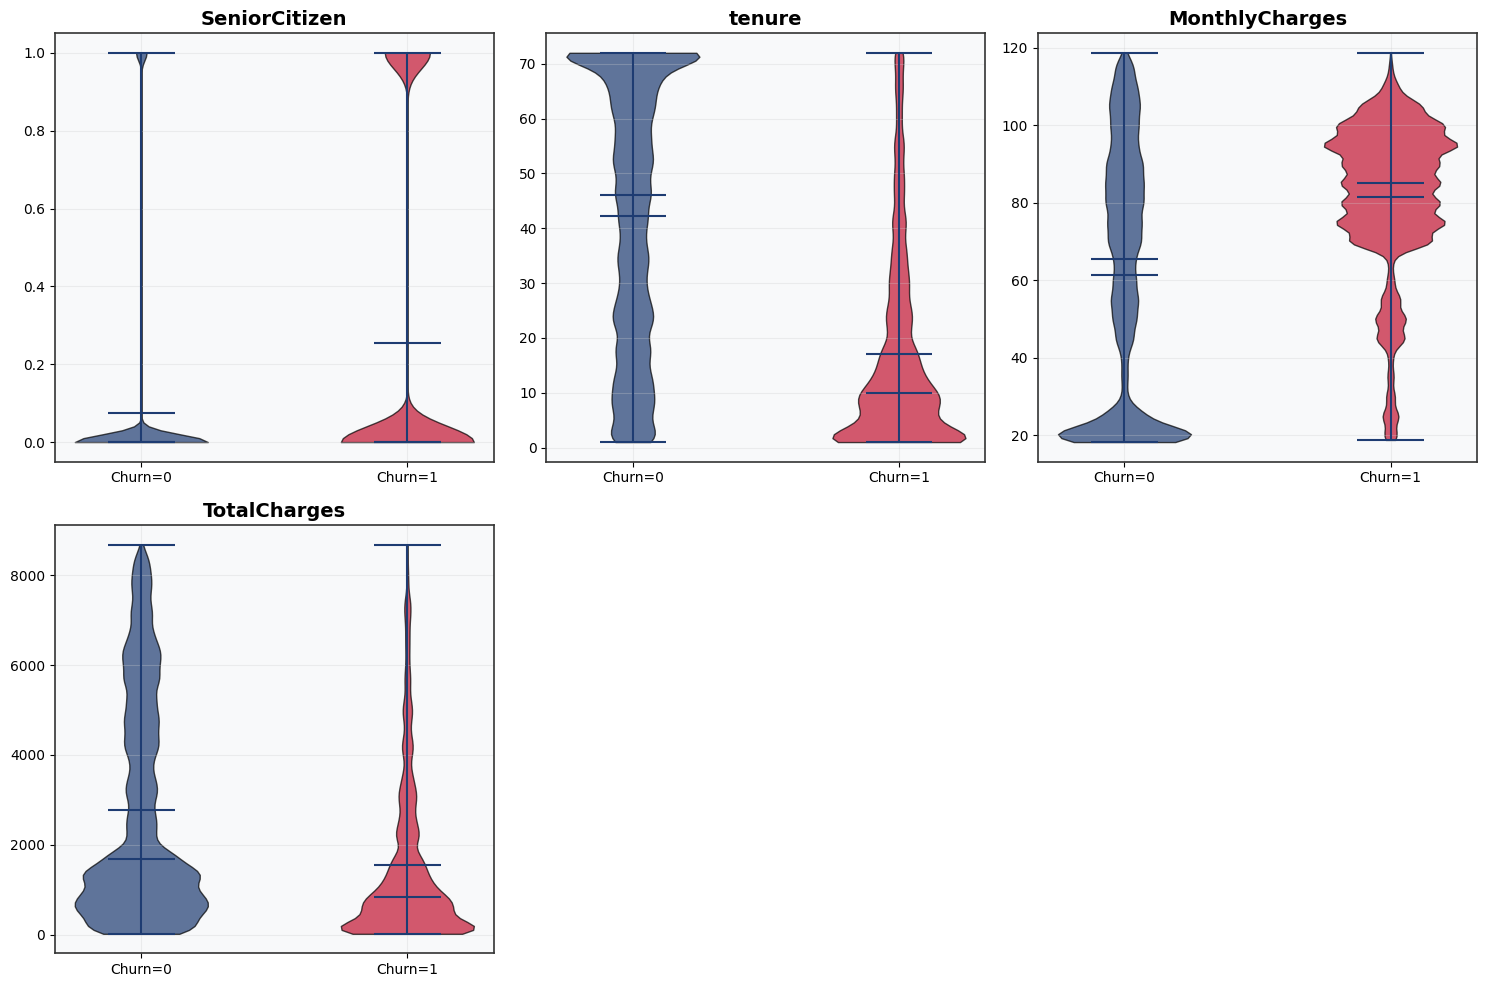

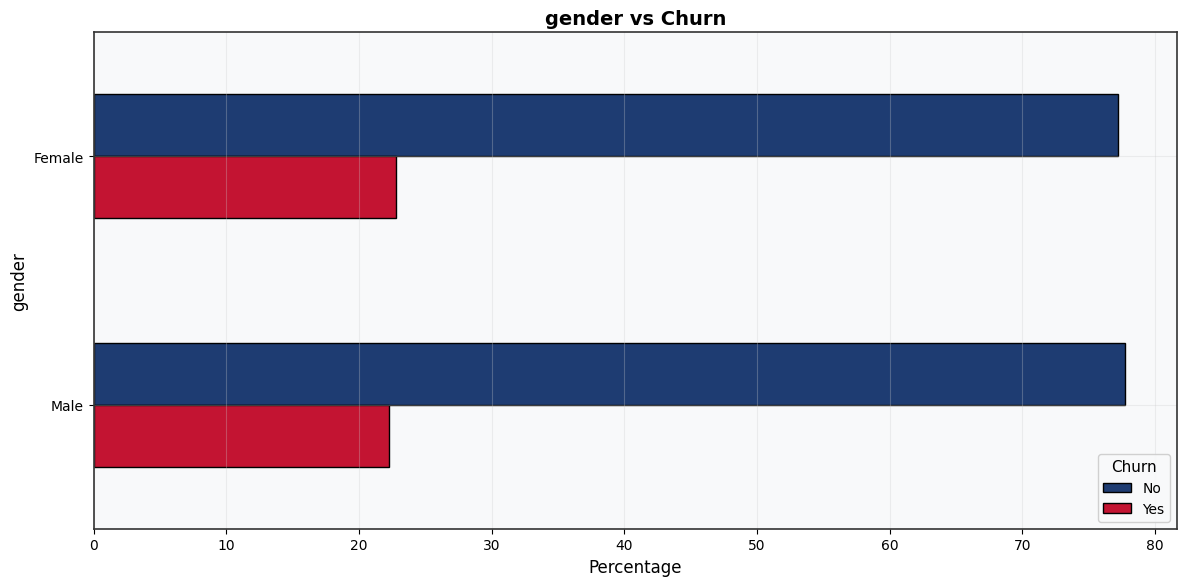

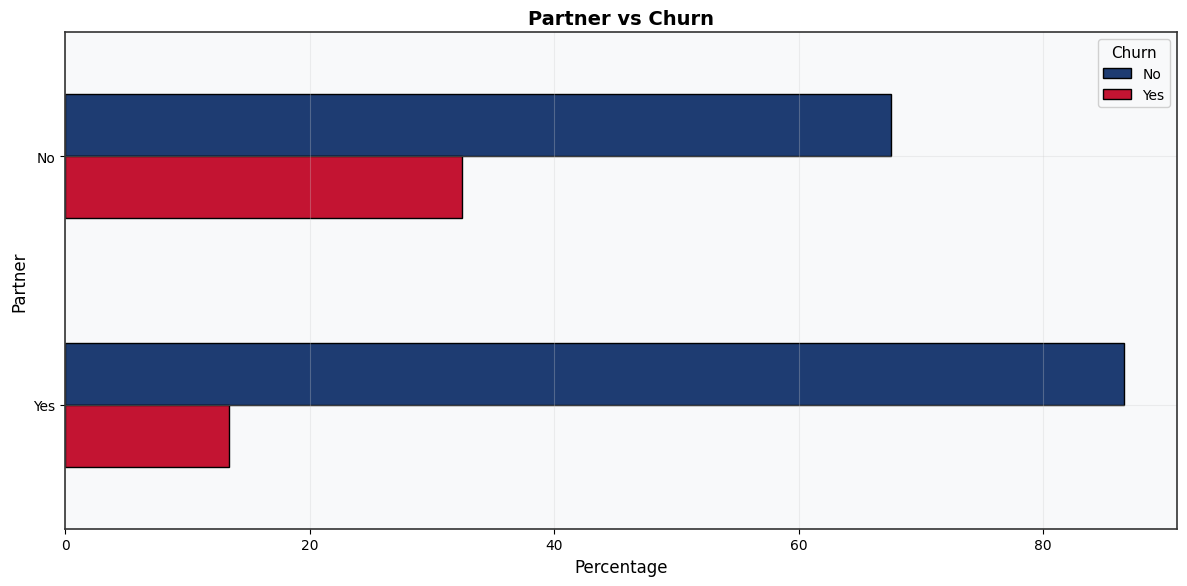

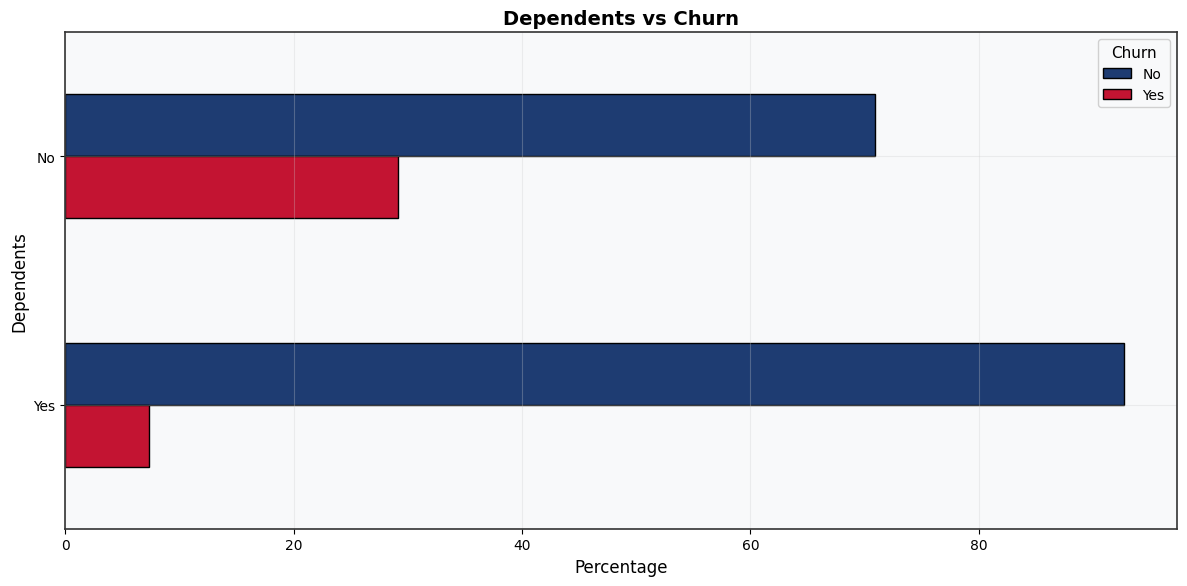

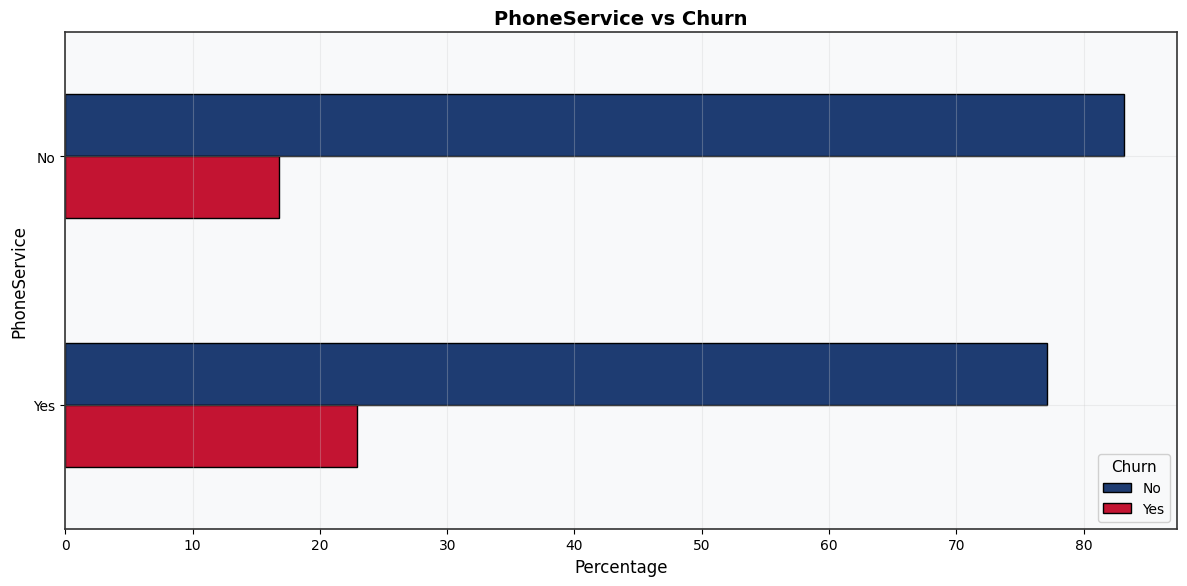

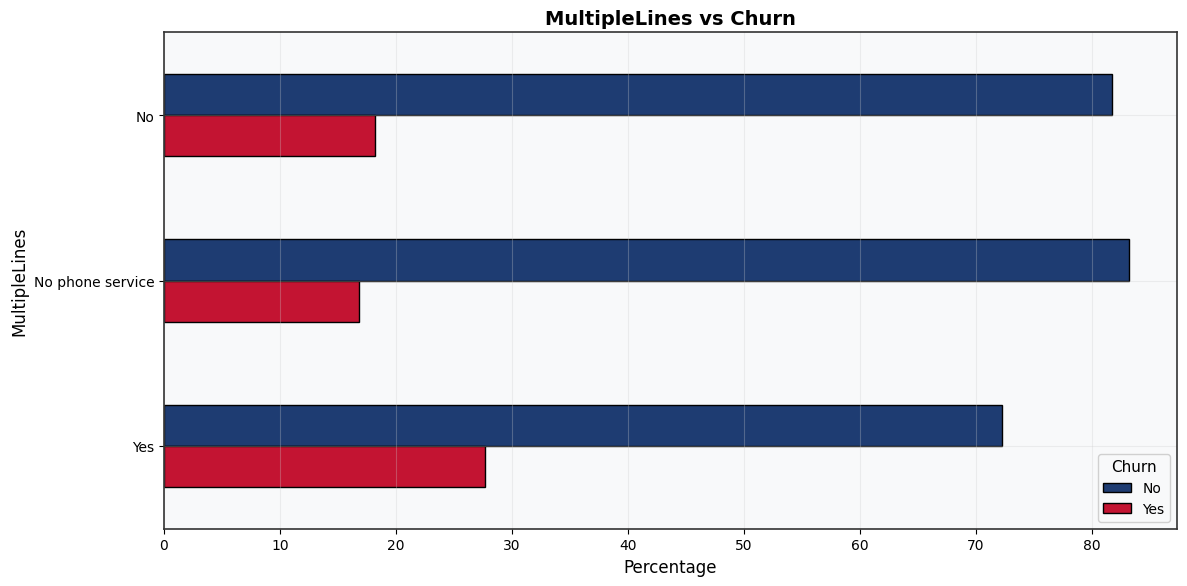

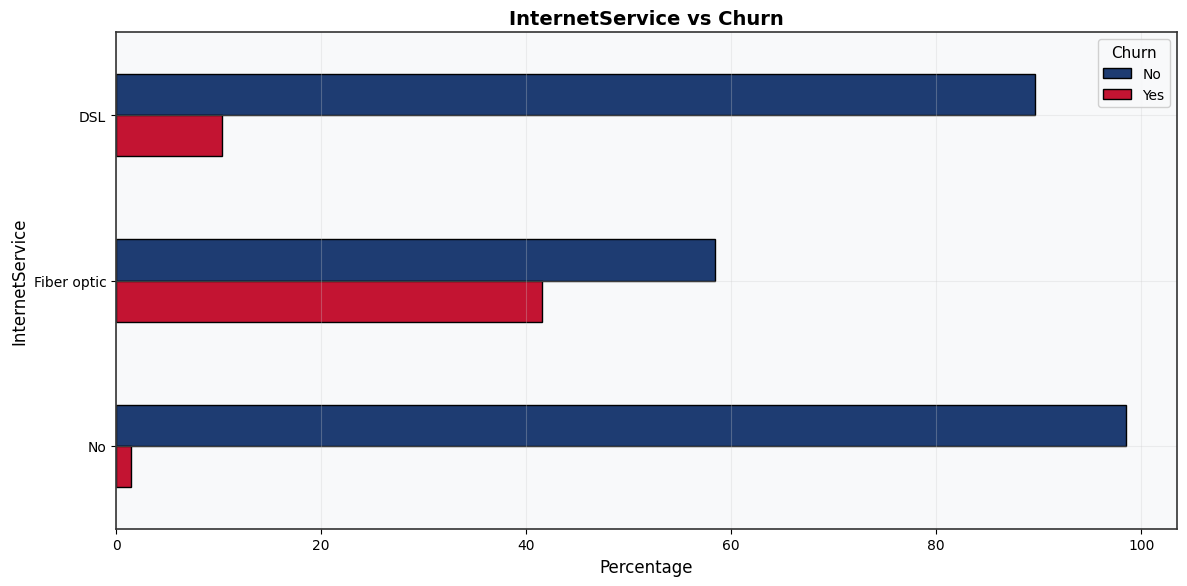

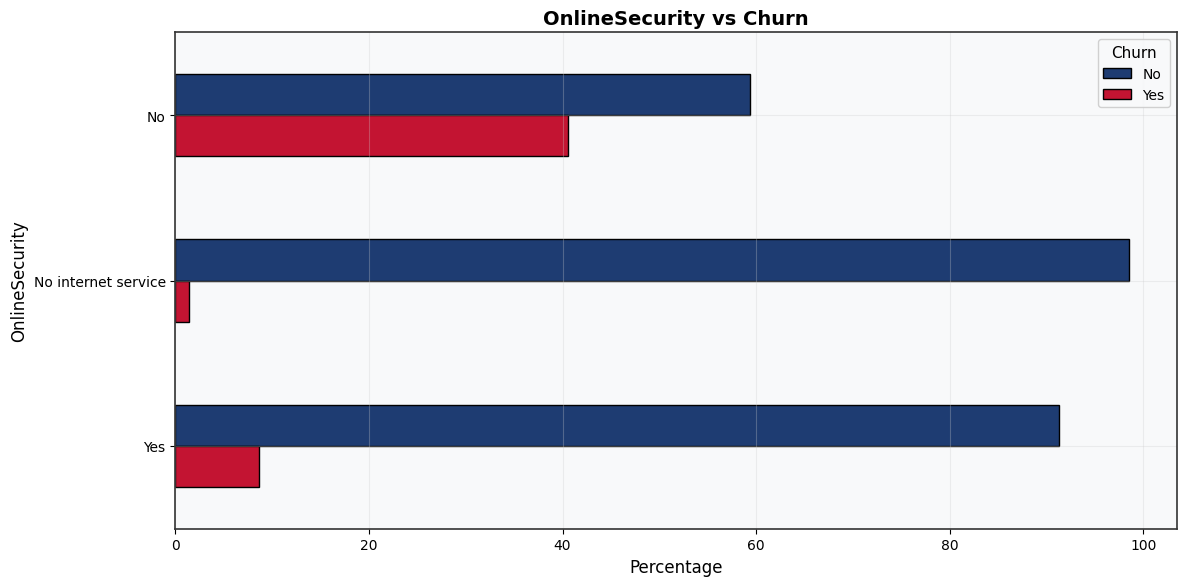

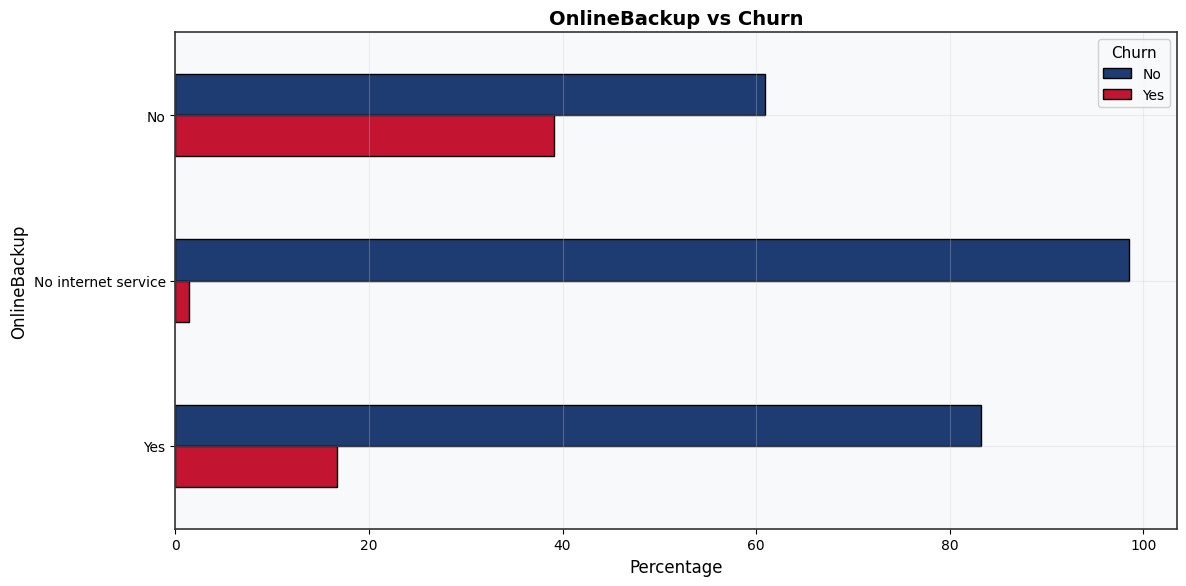

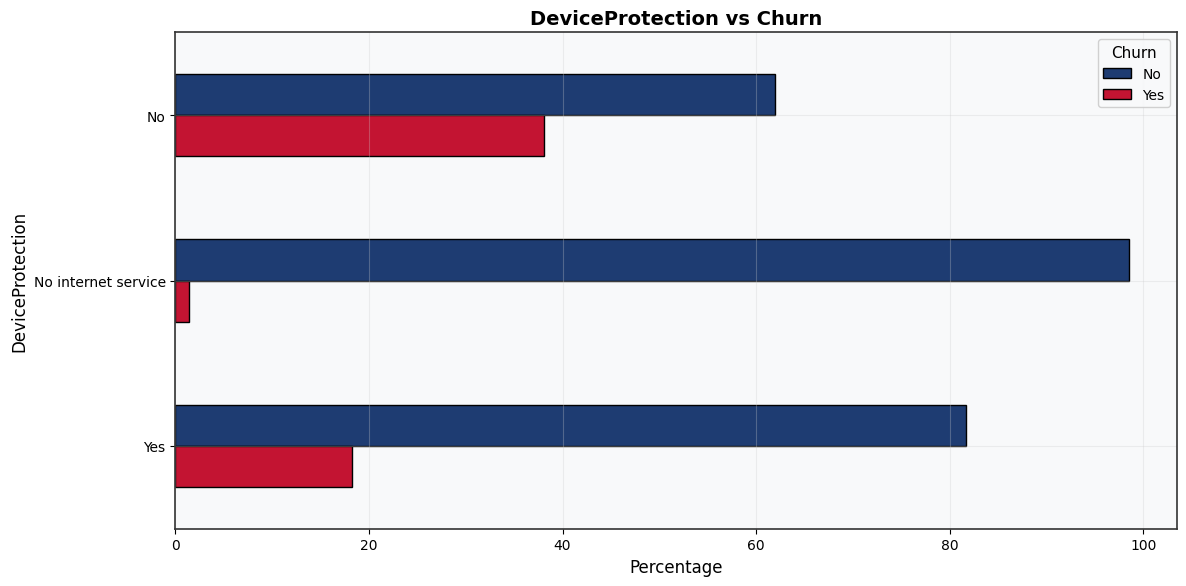

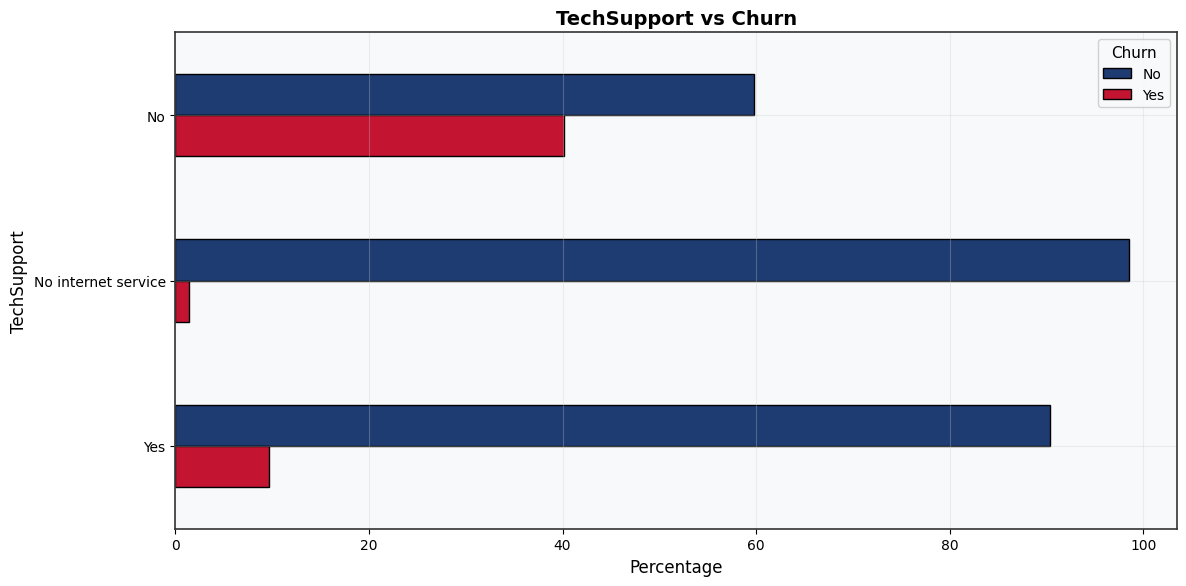

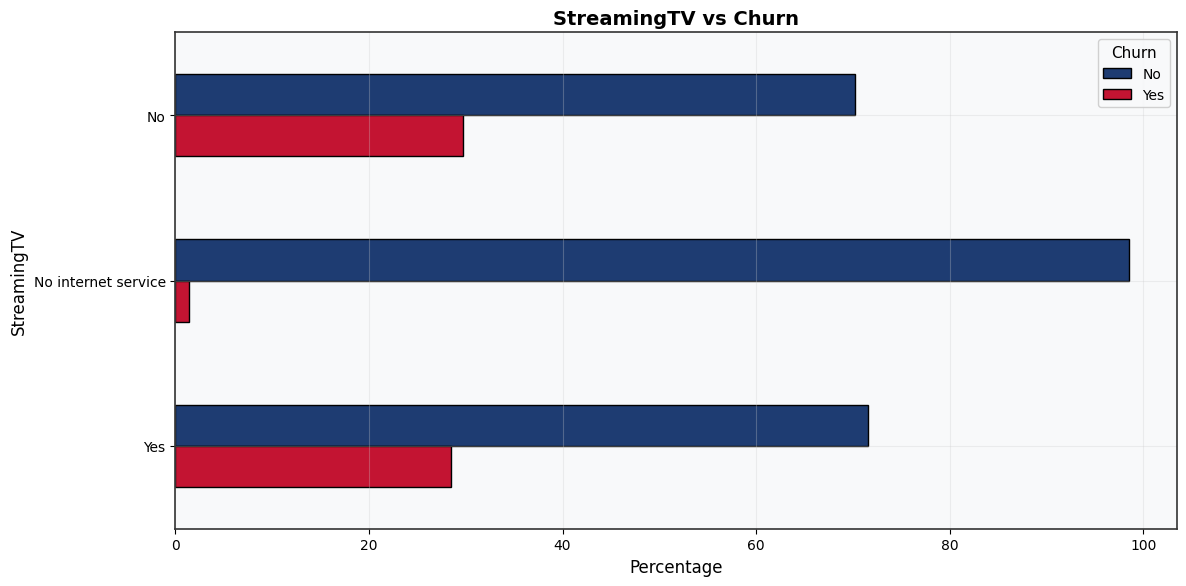

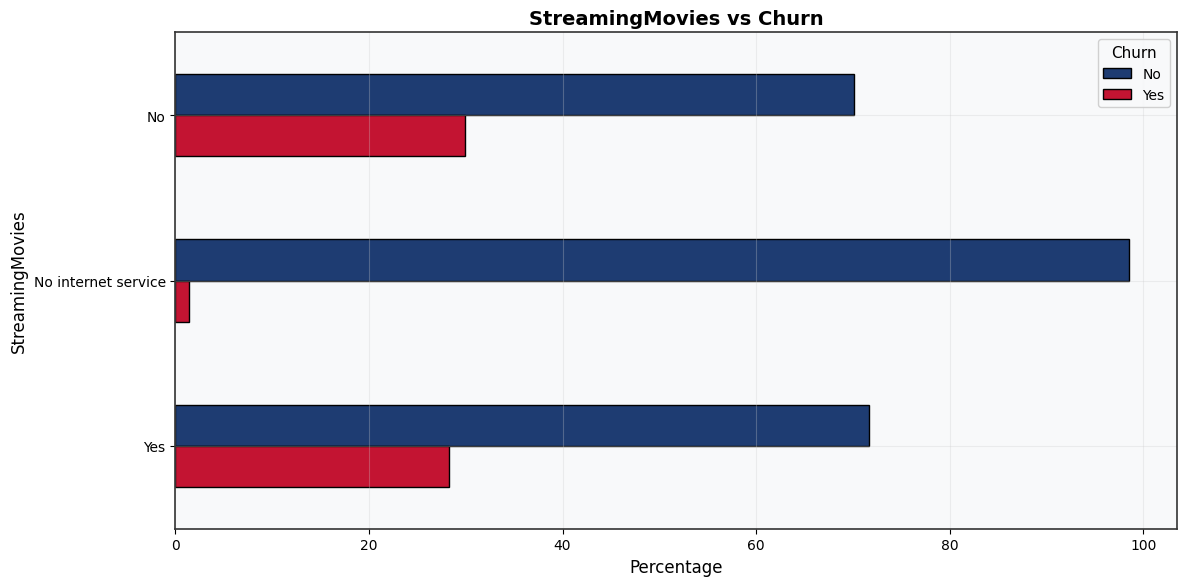

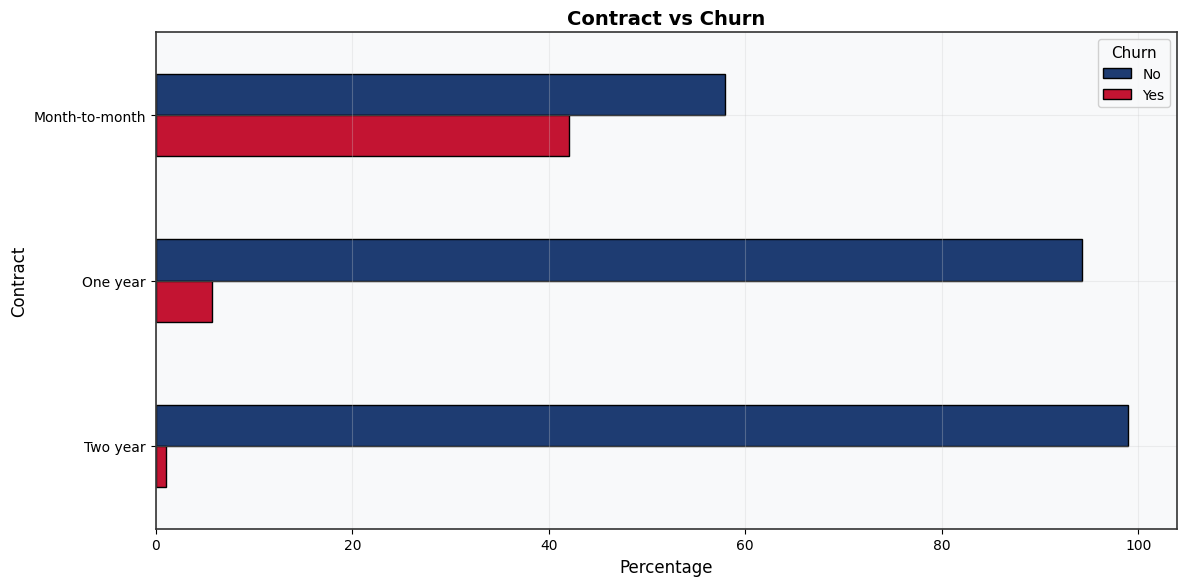

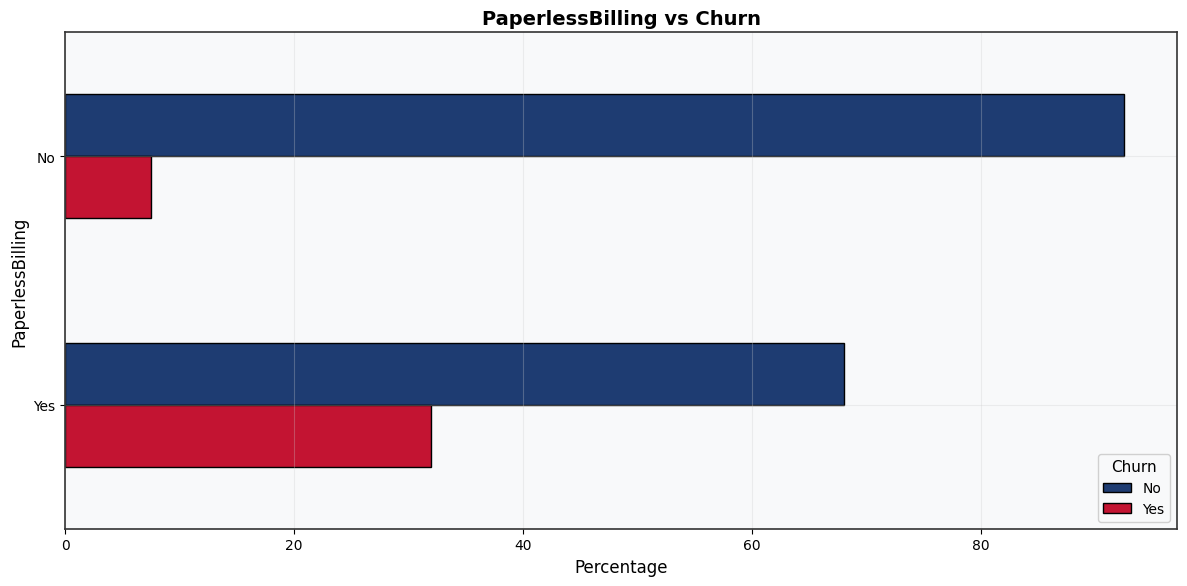

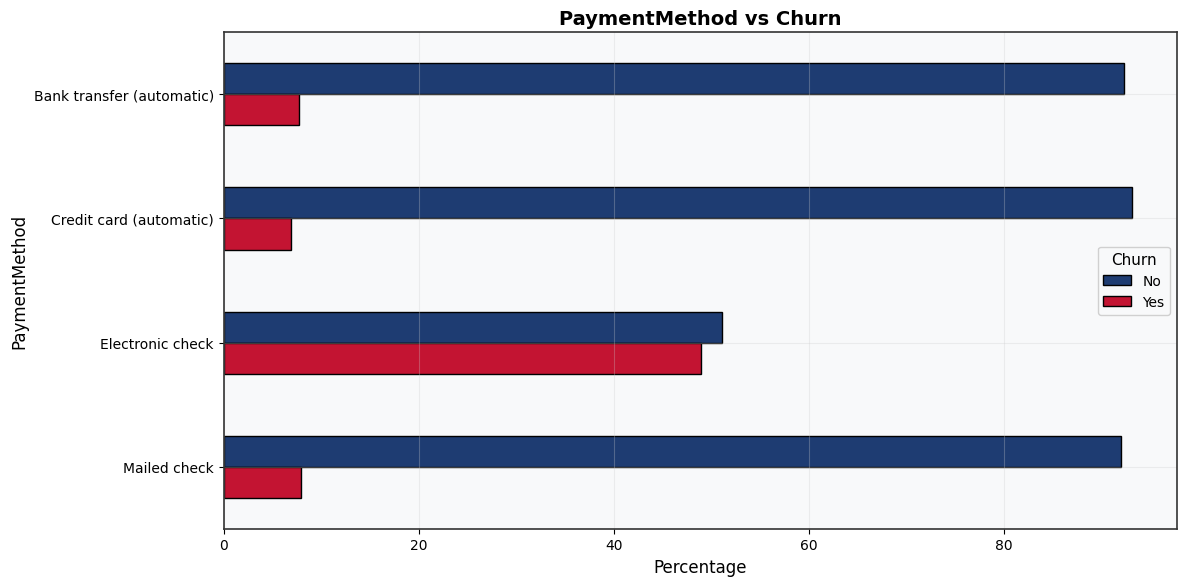


--- INSIGHTS: FEATURE vs TARGET
[i] Numerical features:
[✓]   SeniorCitizen: clear separation (churn mean 0.25 vs non‑churn 0.07)
[✓]   tenure: clear separation (churn mean 17.13 vs non‑churn 42.23)
[✓]   MonthlyCharges: clear separation (churn mean 81.60 vs non‑churn 61.29)
[✓]   TotalCharges: clear separation (churn mean 1540.98 vs non‑churn 2771.50)
[i] Categorical features:
[i]   gender: highest churn rate in 'Female' (22.8%)
[i]   Partner: highest churn rate in 'No' (32.5%)
[i]   Dependents: highest churn rate in 'No' (29.1%)
[i]   PhoneService: highest churn rate in 'Yes' (22.9%)
[i]   MultipleLines: highest churn rate in 'Yes' (27.7%)
[i]   InternetService: highest churn rate in 'Fiber optic' (41.5%)
[i]   OnlineSecurity: highest churn rate in 'No' (40.6%)
[i]   OnlineBackup: highest churn rate in 'No' (39.1%)
[i]   DeviceProtection: highest churn rate in 'No' (38.1%)
[i]   TechSupport: highest churn rate in 'No' (40.2%)
[i]   StreamingTV: highest churn rate in 'No' (29.7%)
[i]

In [3]:
class EDAPipeline:
    """
    Performs comprehensive exploratory data analysis with enhanced insights.
    """

    def __init__(self, train_path: str, test_path: str, original_path: str, target_col: str = 'Churn'):
        self.train_path = train_path
        self.test_path = test_path
        self.original_path = original_path
        self.target = target_col
        self.train = None
        self.test = None
        self.original = None
        self.numerical_cols = None
        self.categorical_cols = None

    def load_data(self) -> None:
        """Load datasets and perform basic checks."""
        Print.header("DATA LOADING")
        self.train = pd.read_csv(self.train_path)
        self.test = pd.read_csv(self.test_path)
        self.original = pd.read_csv(self.original_path)

        # Map target to binary
        if self.train[self.target].dtype == 'object':
            self.train[self.target] = self.train[self.target].map({'No': 0, 'Yes': 1})

        Print.success(f"Train shape: {self.train.shape}")
        Print.success(f"Test shape : {self.test.shape}")
        Print.success(f"Original shape: {self.original.shape}")

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: DATA LOADING")
        Print.info(f"Training set contains {self.train.shape[0]:,} rows and {self.train.shape[1]} columns.")
        Print.info(f"Test set contains {self.test.shape[0]:,} rows and {self.test.shape[1]} columns.")
        Print.info(f"Original dataset (IBM sample) has {self.original.shape[0]:,} rows.")
        Print.success("Data loaded successfully. Target variable already binarized for training set.")
        Print.divider()

    def dataset_overview(self) -> None:
        """First few rows, dtypes, summary statistics, and a detailed feature summary table."""
        Print.header("DATASET OVERVIEW")
        print_table(self.train.head(10), "Training data sample")
        print_table(self.train.dtypes.to_frame('dtype').T, "Data types")
        print_table(self.train.describe(include=np.number).T, "Statistical summary (Numerical Columns)")

        # Feature summary table
        summary_data = []
        for col in self.train.columns:
            null_count = self.train[col].isnull().sum()
            null_pct = (null_count / len(self.train)) * 100
            sample_vals = self.train[col].dropna().head(3).tolist()
            sample_str = str(sample_vals)[:50]
            summary_data.append({
                'Column': col,
                'Dtype': str(self.train[col].dtype),
                'Unique': self.train[col].nunique(),
                'Null_Count': null_count,
                'Null_%': f"{null_pct:.2f}%",
                'Sample_Values': sample_str
            })
        summary_df = pd.DataFrame(summary_data)
        print_table(summary_df, "Feature Summary")

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: DATASET OVERVIEW")
        # Identify column types
        num_cols = self.train.select_dtypes(include=['int64', 'float64']).columns.tolist()
        cat_cols = self.train.select_dtypes(include=['object']).columns.tolist()
        Print.info(f"Found {len(num_cols)} numerical features and {len(cat_cols)} categorical features.")
        # Check for any columns with many unique values
        high_cardinality = [col for col in cat_cols if self.train[col].nunique() > 10]
        if high_cardinality:
            Print.warning(f"High cardinality categorical columns: {high_cardinality}")
        else:
            Print.success("All categorical columns have low cardinality (≤10 unique values).")
        Print.divider()

    def missing_values_analysis(self) -> None:
        """Analyse missing values (if any) with heatmap and bar chart."""
        Print.header("MISSING VALUES ANALYSIS")
        missing_train = self.train.isnull().sum()
        missing_test = self.test.isnull().sum()
        if missing_train.sum() == 0 and missing_test.sum() == 0:
            Print.success("No missing values detected.")
        else:
            Print.warning("Missing values found!")
            # Plot heatmap for a sample
            sample = self.train.sample(min(500, len(self.train)), random_state=42)
            plt.figure(figsize=(14, 6))
            sns.heatmap(sample.isnull(), cmap='Purples', cbar=True, yticklabels=False)
            plt.title('Missing Values Heatmap (Sample)')
            plt.tight_layout()
            plt.show()
            plt.close()

            # Bar chart comparison
            train_missing = (missing_train[missing_train > 0] / len(self.train) * 100).sort_values(ascending=False)
            test_missing = (missing_test[missing_test > 0] / len(self.test) * 100).sort_values(ascending=False)
            if len(train_missing) > 0 or len(test_missing) > 0:
                all_missing = pd.concat([train_missing, test_missing], axis=1, keys=['Train', 'Test']).fillna(0)
                all_missing.plot(kind='barh', color=[COLORS[0], COLORS[2]], edgecolor='black')
                plt.xlabel('Missing %')
                plt.title('Missing Values: Train vs Test')
                plt.tight_layout()
                plt.show()
                plt.close()

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: MISSING VALUES")
        if missing_train.sum() == 0 and missing_test.sum() == 0:
            Print.success("No missing values in either train or test set – great!")
        else:
            Print.warning(f"Train missing: {missing_train.sum()} values across {len(missing_train[missing_train>0])} columns.")
            Print.warning(f"Test missing: {missing_test.sum()} values across {len(missing_test[missing_test>0])} columns.")
            Print.info("Consider imputation or removal of affected rows/columns.")
        Print.divider()

    def target_analysis(self) -> None:
        """Analyse target distribution and compare with original dataset."""
        Print.header("TARGET VARIABLE ANALYSIS")
        # Counts and proportions
        counts = self.train[self.target].value_counts()
        percents = self.train[self.target].value_counts(normalize=True) * 100
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # Count bar
        axes[0].bar(counts.index.astype(str), counts.values, color=[COLORS[0], COLORS[1]], edgecolor='black')
        axes[0].set_title('Target Distribution (Count)')
        axes[0].set_xlabel('Churn')
        axes[0].set_ylabel('Count')
        for i, v in enumerate(counts.values):
            axes[0].text(i, v + 1000, f"{v}\n({percents.iloc[i]:.1f}%)", ha='center', va='bottom')
        # Pie chart
        axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%',
                    colors=[COLORS[0], COLORS[1]], explode=(0.05, 0.05))
        axes[1].set_title('Target Distribution (Proportion)')
        plt.tight_layout()
        plt.show()
        plt.close()

        # Compare with original
        if 'Churn' in self.original.columns:
            orig_target = self.original['Churn'].map({'No': 0, 'Yes': 1}) if self.original['Churn'].dtype == 'object' else self.original['Churn']
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            # Grouped bar
            train_pct = self.train[self.target].value_counts(normalize=True) * 100
            orig_pct = orig_target.value_counts(normalize=True) * 100
            x = np.arange(2)
            axes[0].bar(x - 0.2, train_pct.sort_index().values, 0.4, label='Competition', color=COLORS[0])
            axes[0].bar(x + 0.2, orig_pct.sort_index().values, 0.4, label='Original', color=COLORS[4])
            axes[0].set_xticks(x)
            axes[0].set_xticklabels(['0', '1'])
            axes[0].set_ylabel('Percentage')
            axes[0].set_title('Target Comparison')
            axes[0].legend()
            # Histogram
            axes[1].hist([self.train[self.target], orig_target], bins=2, label=['Competition', 'Original'],
                         color=[COLORS[0], COLORS[4]], edgecolor='black')
            axes[1].set_title('Raw Counts')
            axes[1].legend()
            plt.tight_layout()
            plt.show()
            plt.close()
            Print.info(f"Competition churn rate: {self.train[self.target].mean()*100:.2f}%")
            Print.info(f"Original churn rate   : {orig_target.mean()*100:.2f}%")

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: TARGET VARIABLE")
        churn_rate = self.train[self.target].mean() * 100
        Print.info(f"Overall churn rate in competition data: {churn_rate:.2f}%.")
        if churn_rate < 15:
            Print.warning("Class imbalance is moderate (churn < 15%). Consider using class_weight or resampling.")
        elif churn_rate < 30:
            Print.info("Class imbalance is mild.")
        else:
            Print.success("Classes are relatively balanced.")
        if 'Churn' in self.original.columns:
            orig_rate = orig_target.mean() * 100
            diff = churn_rate - orig_rate
            Print.info(f"Original dataset churn rate: {orig_rate:.2f}%.")
            if abs(diff) > 5:
                Print.warning(f"Competition churn rate differs by {diff:.2f}% from original – distributions may not be identical.")
            else:
                Print.success("Competition and original churn rates are similar.")
        Print.divider()

    def numerical_analysis(self) -> None:
        """Analyse numerical features: histograms, boxplots, skewness."""
        Print.header("NUMERICAL FEATURES ANALYSIS")
        self.numerical_cols = self.train.select_dtypes(include=['int64', 'float64']).columns.tolist()
        self.numerical_cols = [c for c in self.numerical_cols if c not in ['id', self.target]]
        if not self.numerical_cols:
            Print.warning("No numerical features found.")
            return

        Print.info(f"Numerical features: {self.numerical_cols}")

        # Histograms with KDE
        n_cols = 3
        n_rows = (len(self.numerical_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
        for idx, col in enumerate(self.numerical_cols):
            ax = axes[idx]
            data = self.train[col].dropna()
            ax.hist(data, bins=30, color=COLORS[0], alpha=0.7, edgecolor='black')
            ax2 = ax.twinx()
            data.plot(kind='kde', ax=ax2, color=COLORS[1], linewidth=2)
            ax2.set_yticks([])
            ax.set_title(col)
        for idx in range(len(self.numerical_cols), len(axes)):
            fig.delaxes(axes[idx])
        plt.tight_layout()
        plt.show()
        plt.close()

        # Boxplots
        n_rows = (len(self.numerical_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
        for idx, col in enumerate(self.numerical_cols):
            ax = axes[idx]
            self.train.boxplot(column=col, ax=ax, patch_artist=True,
                               boxprops=dict(facecolor=COLORS[0], color='black'),
                               whiskerprops=dict(color='black'), capprops=dict(color='black'),
                               medianprops=dict(color='red', linewidth=2))
            ax.set_title(col)
        for idx in range(len(self.numerical_cols), len(axes)):
            fig.delaxes(axes[idx])
        plt.tight_layout()
        plt.show()
        plt.close()

        # Skewness summary
        skewness = {col: self.train[col].skew() for col in self.numerical_cols}
        skew_df = pd.DataFrame(list(skewness.items()), columns=['Feature', 'Skewness']).sort_values('Skewness')
        fig, ax = plt.subplots(figsize=(10, max(6, len(self.numerical_cols)*0.4)))
        colors_skew = [COLORS[0] if x > 0 else COLORS[3] for x in skew_df['Skewness']]
        ax.barh(skew_df['Feature'], skew_df['Skewness'], color=colors_skew, edgecolor='black')
        ax.axvline(1, color='red', linestyle='--', alpha=0.7, label='±1 threshold')
        ax.axvline(-1, color='red', linestyle='--', alpha=0.7)
        ax.axvline(0, color='black', linestyle='-', alpha=0.5)
        ax.set_xlabel('Skewness')
        ax.set_title('Feature Skewness')
        ax.legend()
        plt.tight_layout()
        plt.show()
        plt.close()

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: NUMERICAL FEATURES")
        for col in self.numerical_cols:
            mean = self.train[col].mean()
            std = self.train[col].std()
            skew = self.train[col].skew()
            Print.info(f"{col}: mean = {mean:.2f}, std = {std:.2f}, skew = {skew:.2f}")
        # Identify skewed features
        skewed = [col for col in self.numerical_cols if abs(self.train[col].skew()) > 1]
        if skewed:
            Print.warning(f"Highly skewed features: {skewed}. Consider log or power transformations.")
        else:
            Print.success("All numerical features have acceptable skew (|skew| ≤ 1).")
        # Outliers from boxplots (simple check)
        outlier_count = {}
        for col in self.numerical_cols:
            Q1 = self.train[col].quantile(0.25)
            Q3 = self.train[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outliers = self.train[(self.train[col] < lower) | (self.train[col] > upper)].shape[0]
            if outliers > 0:
                outlier_count[col] = outliers
        if outlier_count:
            Print.warning(f"Columns with outliers: {outlier_count}. Robust scaling or winsorization may help.")
        else:
            Print.success("No significant outliers detected in boxplots.")
        Print.divider()

    def categorical_analysis(self) -> None:
        """Analyse categorical features: value counts, cardinality."""
        Print.header("CATEGORICAL FEATURES ANALYSIS")
        self.categorical_cols = self.train.select_dtypes(include=['object']).columns.tolist()
        self.categorical_cols = [c for c in self.categorical_cols if c not in ['id']]
        if not self.categorical_cols:
            Print.warning("No categorical features found.")
            return

        Print.info(f"Categorical features: {self.categorical_cols}")

        # Value count distributions for each categorical feature
        for col in self.categorical_cols:
            vc = self.train[col].value_counts().head(15)
            pct = (vc / len(self.train) * 100)
            fig, ax = plt.subplots(figsize=(12, max(6, len(vc)*0.4)))
            bars = ax.barh(range(len(vc)), vc.values, color=COLORS[:len(vc)], edgecolor='black')
            ax.set_yticks(range(len(vc)))
            ax.set_yticklabels(vc.index)
            ax.set_xlabel('Count')
            ax.set_title(f'{col} - Value Distribution')
            ax.invert_yaxis()
            for i, (bar, count, perc) in enumerate(zip(bars, vc.values, pct.values)):
                ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                        f'  {count:,} ({perc:.1f}%)', ha='left', va='center')
            plt.tight_layout()
            plt.show()
            plt.close()

        # Cardinality overview
        cardinality = {col: self.train[col].nunique() for col in self.categorical_cols}
        card_df = pd.DataFrame(list(cardinality.items()), columns=['Feature', 'Unique Values']).sort_values('Unique Values', ascending=False)
        fig, ax = plt.subplots(figsize=(10, max(6, len(self.categorical_cols)*0.4)))
        card_bars = ax.barh(card_df['Feature'], card_df['Unique Values'], color=COLORS[0], edgecolor='black')
        ax.set_xlabel('Number of unique values')
        ax.set_title('Categorical Feature Cardinality')
        ax.invert_yaxis()
        for bar in card_bars:
            ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'  {int(bar.get_width())}', ha='left', va='center')
        plt.tight_layout()
        plt.show()
        plt.close()

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: CATEGORICAL FEATURES")
        for col in self.categorical_cols:
            top_cat = self.train[col].value_counts().index[0]
            top_pct = self.train[col].value_counts(normalize=True).iloc[0] * 100
            Print.info(f"{col}: most frequent category '{top_cat}' appears in {top_pct:.1f}% of rows.")
        # High cardinality again
        high_card = {col: card for col, card in cardinality.items() if card > 10}
        if high_card:
            Print.warning(f"High cardinality columns: {high_card}. Consider encoding strategies.")
        else:
            Print.success("All categorical features have low cardinality, suitable for one‑hot encoding.")
        Print.divider()

    def feature_vs_target(self) -> None:
        """Analyse relationship between features and target."""
        Print.header("FEATURE vs TARGET ANALYSIS")

        # Numerical vs target: violin plots
        if self.numerical_cols:
            n_cols = 3
            n_rows = (len(self.numerical_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
            axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
            for idx, col in enumerate(self.numerical_cols):
                ax = axes[idx]
                data_to_plot = [self.train[self.train[self.target] == val][col].dropna() for val in sorted(self.train[self.target].unique())]
                parts = ax.violinplot(data_to_plot, positions=range(len(data_to_plot)), showmeans=True, showmedians=True)
                for i, pc in enumerate(parts['bodies']):
                    pc.set_facecolor(COLORS[i % 2])
                    pc.set_alpha(0.7)
                    pc.set_edgecolor('black')
                ax.set_xticks(range(len(data_to_plot)))
                ax.set_xticklabels([f'Churn={v}' for v in sorted(self.train[self.target].unique())])
                ax.set_title(col)
            for idx in range(len(self.numerical_cols), len(axes)):
                fig.delaxes(axes[idx])
            plt.tight_layout()
            plt.show()
            plt.close()

        # Categorical vs target: stacked bar charts
        if self.categorical_cols:
            for col in self.categorical_cols:
                ct = pd.crosstab(self.train[col], self.train[self.target], normalize='index') * 100
                fig, ax = plt.subplots(figsize=(12, max(6, len(ct)*0.4)))
                ct.plot(kind='barh', stacked=False, ax=ax, color=[COLORS[0], COLORS[1]], edgecolor='black')
                ax.set_xlabel('Percentage')
                ax.set_ylabel(col)
                ax.set_title(f'{col} vs Churn')
                ax.legend(title='Churn', labels=['No', 'Yes'])
                ax.invert_yaxis()
                plt.tight_layout()
                plt.show()
                plt.close()

        # ---- INSIGHTS ----
        Print.header("INSIGHTS: FEATURE vs TARGET")
        if self.numerical_cols:
            Print.info("Numerical features:")
            for col in self.numerical_cols:
                # Compare means for churn vs non-churn
                mean0 = self.train[self.train[self.target] == 0][col].mean()
                mean1 = self.train[self.train[self.target] == 1][col].mean()
                diff = mean1 - mean0
                if abs(diff) > 0.2 * self.train[col].std():  # heuristic
                    Print.success(f"  {col}: clear separation (churn mean {mean1:.2f} vs non‑churn {mean0:.2f})")
                else:
                    Print.info(f"  {col}: similar distributions (churn mean {mean1:.2f} vs non‑churn {mean0:.2f})")
        if self.categorical_cols:
            Print.info("Categorical features:")
            for col in self.categorical_cols:
                # Identify categories with highest churn rate
                churn_rates = self.train.groupby(col)[self.target].mean().sort_values(ascending=False)
                top_cat = churn_rates.index[0]
                top_rate = churn_rates.iloc[0] * 100
                Print.info(f"  {col}: highest churn rate in '{top_cat}' ({top_rate:.1f}%)")
        Print.divider()

    def run_eda(self):
        """Execute the complete EDA workflow."""
        self.load_data()
        self.dataset_overview()
        self.missing_values_analysis()
        self.target_analysis()
        self.numerical_analysis()
        self.categorical_analysis()
        self.feature_vs_target()
        Print.success("EDA completed.")

# ------------------------------------------------------------------------------
# Main execution for EDA
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    set_plot_style()

    CONFIG = {
        'TRAIN_PATH': '/kaggle/input/competitions/playground-series-s6e3/train.csv',
        'TEST_PATH': '/kaggle/input/competitions/playground-series-s6e3/test.csv',
        'ORIGINAL_PATH': '/kaggle/input/datasets/thedrzee/customer-churn-in-telecom-sample-dataset-by-ibm/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        'TARGET': 'Churn',
    }

    eda = EDAPipeline(
        train_path=CONFIG['TRAIN_PATH'],
        test_path=CONFIG['TEST_PATH'],
        original_path=CONFIG['ORIGINAL_PATH'],
        target_col=CONFIG['TARGET']
    )
    eda.run_eda()

# Feature Engineering Pipeline

In [4]:
class FeatureEngineeringPipeline:

    def __init__(self, target_col: str = 'Churn', random_state: int = 42):
        self.target = target_col
        self.random_state = random_state
        self.column_transformer = None
        self.X_combined = None
        self.y_combined = None
        self.X_test = None
        self.feature_names = None

    def _add_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add new features to the dataframe."""
        df = df.copy()

        # TotalCharges per tenure (handle division by zero)
        df['TotalCharges_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

        # MonthlyCharges per tenure
        df['MonthlyCharges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

        # Tenure group
        bins = [0, 6, 12, 24, 48, 72, 100]
        labels = ['0-6', '6-12', '12-24', '24-48', '48-72', '72+']
        df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

        # Average monthly charges (TotalCharges / tenure, but tenure may be zero)
        df['avg_monthly_charges'] = df['TotalCharges'] / (df['tenure'] + 1)

        # Interaction: OnlineSecurity & TechSupport
        if 'OnlineSecurity' in df.columns and 'TechSupport' in df.columns:
            df['Security_TechSupport'] = (
                (df['OnlineSecurity'] == 'Yes') & (df['TechSupport'] == 'Yes')
            ).astype(int)

        # Interaction: StreamingTV & StreamingMovies
        if 'StreamingTV' in df.columns and 'StreamingMovies' in df.columns:
            df['Both_Streaming'] = (
                (df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')
            ).astype(int)

        # Number of add-on services (count of 'Yes' in service columns)
        service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']
        present_service_cols = [col for col in service_cols if col in df.columns]
        if present_service_cols:
            df['num_services'] = (df[present_service_cols] == 'Yes').sum(axis=1)

        return df

    def fit_transform(self, train_df: pd.DataFrame, original_df: pd.DataFrame, test_df: pd.DataFrame = None):
        """
        Clean, merge, engineer features, fit preprocessor on combined data,
        transform both combined and test data.
        """
        Print.header("FEATURE ENGINEERING & PREPROCESSING (with original data merge)")

        # --- Clean original dataset ---
        if 'TotalCharges' in original_df.columns:
            original_df['TotalCharges'] = pd.to_numeric(original_df['TotalCharges'], errors='coerce')
        if 'customerID' in original_df.columns:
            original_df = original_df.drop(columns=['customerID'])
        if self.target in original_df.columns and original_df[self.target].dtype == 'object':
            original_df[self.target] = original_df[self.target].map({'No': 0, 'Yes': 1})

        # --- Merge competition train and original data ---
        combined = pd.concat([train_df, original_df], axis=0, ignore_index=True)
        Print.info(f"Combined training data shape (before engineering): {combined.shape}")

        # --- Feature engineering on combined data ---
        combined = self._add_features(combined)
        Print.info(f"Combined training data shape (after engineering): {combined.shape}")

        # Separate features and target
        X_combined = combined.drop(columns=[self.target, 'id'], errors='ignore')
        y_combined = combined[self.target].values

        # Identify column types
        numerical_cols = X_combined.select_dtypes(include=['int64', 'float64']).columns.tolist()
        categorical_cols = X_combined.select_dtypes(include=['object', 'category']).columns.tolist()

        Print.info(f"Numerical columns: {numerical_cols}")
        Print.info(f"Categorical columns: {categorical_cols}")

        # Build transformers
        numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])

        self.column_transformer = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_cols),
                ('cat', categorical_transformer, categorical_cols)
            ])

        # Fit and transform combined data
        X_combined_transformed = self.column_transformer.fit_transform(X_combined)
        self.X_combined = X_combined_transformed
        self.y_combined = y_combined

        # Store feature names for later use
        num_features = numerical_cols
        cat_features = self.column_transformer.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
        self.feature_names = np.concatenate([num_features, cat_features])

        Print.success(f"Combined training size: {len(self.y_combined)}")

        if test_df is not None:
            # Apply same feature engineering to test
            test_df_eng = self._add_features(test_df)
            X_test = test_df_eng.drop(columns=['id'], errors='ignore')
            self.X_test = self.column_transformer.transform(X_test)

        Print.divider()
        return self.X_combined, self.y_combined, self.X_test, self.feature_names


# ------------------------------------------------------------------------------
# Main execution for feature engineering & preprocessing 
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    set_plot_style()

    CONFIG = {
        'TRAIN_PATH': '/kaggle/input/competitions/playground-series-s6e3/train.csv',
        'TEST_PATH': '/kaggle/input/competitions/playground-series-s6e3/test.csv',
        'ORIGINAL_PATH': '/kaggle/input/datasets/thedrzee/customer-churn-in-telecom-sample-dataset-by-ibm/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        'TARGET': 'Churn',
        'RANDOM_SEED': 42,
    }

    # Load raw data
    train_df = pd.read_csv(CONFIG['TRAIN_PATH'])
    test_df = pd.read_csv(CONFIG['TEST_PATH'])
    original_df = pd.read_csv(CONFIG['ORIGINAL_PATH'])

    # Map target in competition train if needed
    if train_df[CONFIG['TARGET']].dtype == 'object':
        train_df[CONFIG['TARGET']] = train_df[CONFIG['TARGET']].map({'No': 0, 'Yes': 1})

    # Run pipeline
    pipe = FeatureEngineeringPipeline(
        target_col=CONFIG['TARGET'],
        random_state=CONFIG['RANDOM_SEED']
    )
    X_combined, y_combined, X_test, feature_names = pipe.fit_transform(train_df, original_df, test_df)

    # Save data
    np.savetxt('X_combined.csv', X_combined, delimiter=',')
    np.savetxt('y_combined.csv', y_combined, delimiter=',')
    np.savetxt('X_test.csv', X_test, delimiter=',')
    # Save feature names for reference
    with open('feature_names.txt', 'w') as f:
        for name in feature_names:
            f.write(f"{name}\n")

    Print.success("Feature‑engineered preprocessed data saved to CSV files.")


--- FEATURE ENGINEERING & PREPROCESSING (with original data merge)
[i] Combined training data shape (before engineering): (601237, 21)
[i] Combined training data shape (after engineering): (601237, 28)
[i] Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_per_tenure', 'MonthlyCharges_per_tenure', 'avg_monthly_charges', 'Security_TechSupport', 'Both_Streaming', 'num_services']
[i] Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
[✓] Combined training size: 601237
[✓] Feature‑engineered preprocessed data saved to CSV files.


# Training Pipeline

[✓] Feature‑engineered data loaded.

--- STACKING TRAINING (GPU, fast mode with early stopping)


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
Default metric period is 5 because AUC is/are not implemented for GPU


[i] Fold 1 completed.


Default metric period is 5 because AUC is/are not implemented for GPU


[i] Fold 2 completed.


...

[i] Fold 4 completed.


Default metric period is 5 because AUC is/are not implemented for GPU


[i] Fold 5 completed.

--- BASE MODEL CROSS‑VALIDATION PERFORMANCE
[i] xgb: CV AUC = 0.9149 ± 0.0009
[i] lgbm: CV AUC = 0.9156 ± 0.0008
[i] catboost: CV AUC = 0.9153 ± 0.0008

--- TRAINING META‑LEARNER (LogisticRegression)
[✓] Meta‑model OOF AUC: 0.9159

--- RETRAINING BASE MODELS ON FULL DATA (with validation)
[✓] xgb retrained.
[✓] lgbm retrained.


Default metric period is 5 because AUC is/are not implemented for GPU


[✓] catboost retrained.


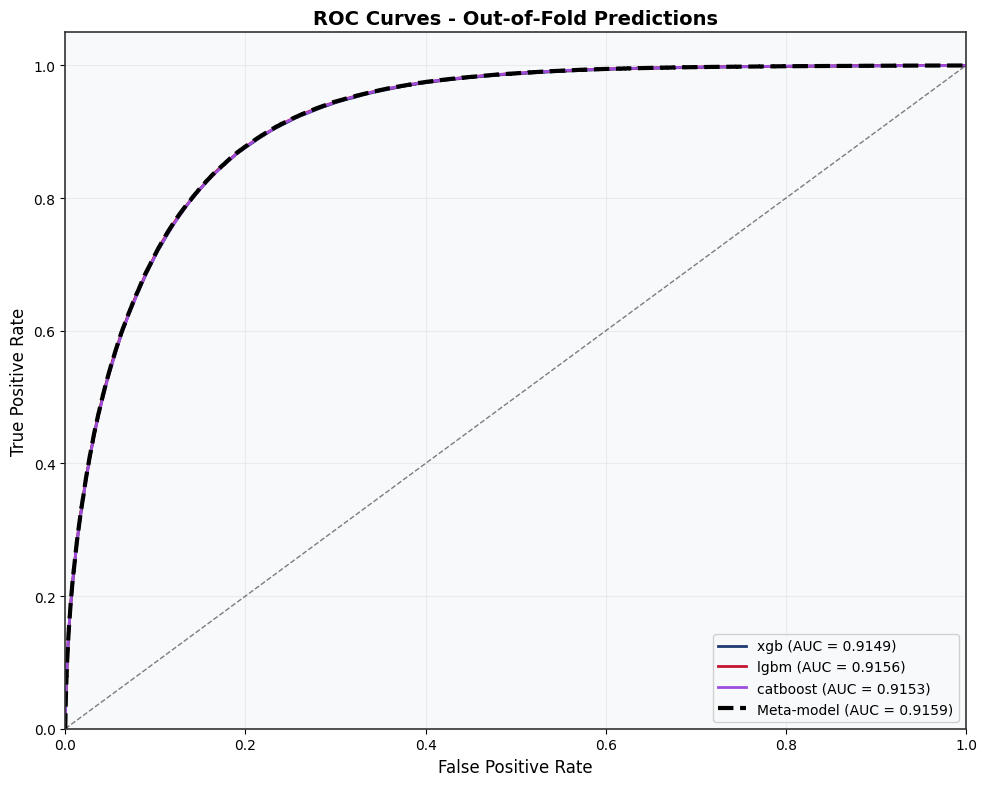

[✓] Submission saved to submission.csv


In [5]:
class StackingTrainingPipeline:

    def __init__(self, n_folds: int = 5, random_state: int = 42):
        self.n_folds = n_folds
        self.random_state = random_state
        self.base_models = []          # list of (name, model) for full retraining
        self.meta_model = None
        self.oof_preds_ = None         # store OOF predictions for plotting
        self.model_names_ = []         # store base model names

    def _get_base_models(self):
        """Return base models with GPU acceleration for all three."""
        SEED = self.random_state

        # XGBoost with GPU
        xgb_model = xgb.XGBClassifier(
            n_estimators=2000,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=SEED,
            eval_metric='auc',
            tree_method='hist',   
            device='cuda',        
            verbosity=0,
            n_jobs=-1
        )
        # LightGBM with GPU
        lgb_model = lgb.LGBMClassifier(
            n_estimators=2000,
            learning_rate=0.05,
            max_depth=7,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=SEED,
            metric='auc',
            device='gpu',
            verbose=-1
        )

        # CatBoost with GPU
        cat_model = cb.CatBoostClassifier(
            iterations=2000,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3.0,
            eval_metric='AUC',
            random_seed=SEED,
            task_type='GPU',
            verbose=False
        )

        return [('xgb', xgb_model), ('lgbm', lgb_model), ('catboost', cat_model)]

    def fit_stack(self, X, y):

        Print.header("STACKING TRAINING (GPU, fast mode with early stopping)")

        base_model_list = self._get_base_models()
        self.model_names_ = [name for name, _ in base_model_list]

        skf = StratifiedKFold(n_splits=self.n_folds, shuffle=True, random_state=self.random_state)

        # Store OOF predictions for each base model
        oof_preds = np.zeros((len(y), len(base_model_list)))
        fold_scores = np.zeros((self.n_folds, len(base_model_list)))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            for i, (name, model) in enumerate(base_model_list):
                # Fresh copy for each fold
                model_clone = self._get_base_models()[i][1]

                if name == 'xgb':
                    model_clone.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
                elif name == 'lgbm':
                    model_clone.fit(
                        X_tr, y_tr,
                        eval_set=[(X_val, y_val)],
                        callbacks=[lgb.early_stopping(100, verbose=False)]
                    )
                else:  # catboost
                    model_clone.fit(
                        X_tr, y_tr,
                        eval_set=(X_val, y_val),
                        early_stopping_rounds=100,
                        verbose=False
                    )

                preds = model_clone.predict_proba(X_val)[:, 1]
                oof_preds[val_idx, i] = preds
                fold_scores[fold-1, i] = roc_auc_score(y_val, preds)

            Print.info(f"Fold {fold} completed.")

        # Store OOF predictions for later plotting
        self.oof_preds_ = oof_preds

        # Report CV scores
        Print.header("BASE MODEL CROSS‑VALIDATION PERFORMANCE")
        for i, name in enumerate(self.model_names_):
            mean_auc = fold_scores[:, i].mean()
            std_auc = fold_scores[:, i].std()
            Print.info(f"{name}: CV AUC = {mean_auc:.4f} ± {std_auc:.4f}")

        # Train meta‑model (LogisticRegression) on OOF predictions
        Print.header("TRAINING META‑LEARNER (LogisticRegression)")
        self.meta_model = LogisticRegression(
            C=0.5,
            penalty='l2',
            solver='lbfgs',
            max_iter=1000,
            random_state=self.random_state
        )
        self.meta_model.fit(oof_preds, y)
        meta_oof_preds = self.meta_model.predict_proba(oof_preds)[:, 1]
        meta_auc = roc_auc_score(y, meta_oof_preds)
        Print.success(f"Meta‑model OOF AUC: {meta_auc:.4f}")

        # Retrain base models on full data with a validation split (to apply early stopping)
        Print.header("RETRAINING BASE MODELS ON FULL DATA (with validation)")
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, random_state=self.random_state, stratify=y
        )

        self.base_models = []  # will hold retrained models
        for i, (name, _) in enumerate(base_model_list):
            model_clone = self._get_base_models()[i][1]
            if name == 'xgb':
                model_clone.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            elif name == 'lgbm':
                model_clone.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(100, verbose=False)]
                )
            else:  # catboost
                model_clone.fit(
                    X_train, y_train,
                    eval_set=(X_val, y_val),
                    early_stopping_rounds=100,
                    verbose=False
                )
            self.base_models.append((name, model_clone))
            Print.success(f"{name} retrained.")

        Print.divider()
        return self

    def predict_proba(self, X):
        """
        Generate predictions using the stacked ensemble:
          - Get predictions from all retrained base models.
          - Combine with meta‑model.
        """
        base_preds = np.zeros((X.shape[0], len(self.base_models)))
        for i, (_, model) in enumerate(self.base_models):
            base_preds[:, i] = model.predict_proba(X)[:, 1]
        final_preds = self.meta_model.predict_proba(base_preds)[:, 1]
        return final_preds

    def plot_roc_curves(self, y_true):
        """
        Plot ROC curves for each base model (using OOF predictions) and the meta‑model.
        Requires that fit_stack has been called (so self.oof_preds_ exists).
        """
        if self.oof_preds_ is None:
            raise RuntimeError("No OOF predictions found. Run fit_stack first.")

        plt.figure(figsize=(10, 8))

        # ROC for each base model
        for i, name in enumerate(self.model_names_):
            fpr, tpr, _ = roc_curve(y_true, self.oof_preds_[:, i])
            auc = roc_auc_score(y_true, self.oof_preds_[:, i])
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')

        # ROC for meta‑model
        meta_preds = self.meta_model.predict_proba(self.oof_preds_)[:, 1]
        fpr_meta, tpr_meta, _ = roc_curve(y_true, meta_preds)
        auc_meta = roc_auc_score(y_true, meta_preds)
        plt.plot(fpr_meta, tpr_meta, lw=3, linestyle='--', color='black',
                 label=f'Meta‑model (AUC = {auc_meta:.4f})')

        # Diagonal line
        plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - Out‑of‑Fold Predictions')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------------------
# Main execution
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    CONFIG = {
        'TARGET': 'Churn',
        'RANDOM_SEED': 42,
        'N_FOLDS': 5,
    }

    # Load preprocessed data from CSV 
    X_combined = np.loadtxt('X_combined.csv', delimiter=',')
    y_combined = np.loadtxt('y_combined.csv', delimiter=',')
    X_test = np.loadtxt('X_test.csv', delimiter=',')

    Print.success("Feature‑engineered data loaded.")

    # Initialize and run stacking pipeline
    stack_pipe = StackingTrainingPipeline(
        n_folds=CONFIG['N_FOLDS'],
        random_state=CONFIG['RANDOM_SEED']
    )
    stack_pipe.fit_stack(X_combined, y_combined)

    # Plot ROC curves using out‑of‑fold predictions
    stack_pipe.plot_roc_curves(y_combined)

    # Generate predictions for test set
    test_preds = stack_pipe.predict_proba(X_test)

    # Create submission 
    test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
    submission = pd.DataFrame({
        'id': test_df['id'],
        'Churn': test_preds
    })
    submission.to_csv('submission.csv', index=False)
    Print.success("Submission saved to submission.csv")